# Исследование рынка общественного питания в Москве

- Автор: Блюхерова Оксана
- Дата: 14.02.26

## Цели и задачи

**Цель:** Провести исследовательский анализ данных заведений общественного питания в городе Москва, выявить наиболее «типичные» заведения и наличие корреляций между характеристиками заведений и их рейтингом, а также выработать рекомендации по факторам, влияющим на выбор типа и локации заведения.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных в столбце `rating` с другими данными и найти успешные практики.
4. Сформулировать выводы и рекомендации по проведённому анализу.

## Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
  - 0 — заведение не является сетевым;
  - 1 — заведение является сетевым.
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:
  - «Средний счёт: 1000–1500 ₽»;
  - «Цена чашки капучино: 130–220 ₽»;
  - «Цена бокала пива: 400–600 ₽».
  - и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

- [Загрузка данных и знакомство с ними](#1_download)

- [Проверка ошибок в данных и их предобработка](#2_data_check)

- [Анализ столбцов данных](#3_column_analysis)

- [Изучение взаимосвязей между данными](#4_correlation_analysis)

- [Анализ ТОП-15 популярных сетевых заведений](#5_top_chain)

- [Итоговый вывод](#6_summary)

____

<a id="#1_download"></a>
## Загрузка данных и знакомство с ними

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

try:
    from phik import phik_matrix
except ImportError:
    !pip install phik
    from phik import phik_matrix

In [2]:
# Загрузка данных 
rest_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [3]:
# Выведем первые 5 строк датафрейма rest_df
rest_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выведем информацию о датафрейма rest_df
rest_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


В таблице `rest_df` 9 колонок и 8406 строк. Наименования столбцов указаны корректно (sneak_case). 
В таблице присутствуют пропуски в столбцах график работы `hours` (есть 7870 значений из 8406) и количество посадочных мест `seats` (указано 4795 значений из 8406).

Если рассматривать типы данных, то можно отметить, что для 6 колонок тип данных представлены типом `object`. Это колонки `id`, `name`, `category`, `address`, `district`, `hours`. Учитывая природу данных  для этих столбцов выбран корректный тип данных. Так как заведения могут начинать и заканчивать работу в абсолютно разное время, то для удобства анализа стоит для столбца `hours` создать дополнительный столбец с признаком работает ли заведение круглосуточно или нет с булевым значение (1 или 0).  

Столбец `rating` представлен типом данных `float64`, так как оценка может быть не целым числом от 0 до 5.0, то сам тип данных корректный, но для оптимизации памяти, можно снизить разрядность.

Столбец `chain` представлен типом `int64`, что соответствует природе данных (булевое значение 1 - сетевое заведение, 0 -нет), но для оптимизации памяти также стоит уменьшить разрядность.

Столбец `seats` представлен типом `float64`, что не соответствует природе данных – количество мест может быть только целочисленным, наличие в столбце пропусков могло послужить причиной некорректного определения типа данных. Необходимо привести данные к корректному формату `int`.

In [5]:
# Выведем первые 5 строк датафрейма rest_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выведем информацию о датафрейма rest_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


В датафрейме `price_df` содержится 5 столбцов и 4058 строк. Названия столбцов корректны и приведены к единому стилю (snake_case). Полностью заполненные данные присутствуют только в столбце id. В остальных признаках наблюдаются пропуски: `price` содержит 3315 значений, `avg_bill` — 3816, `middle_avg_bill` — 3149.

Особое внимание стоит уделить столбцу `middle_coffee_cup`, где заполнено всего 535 значений (13,2%). Такое количество данных может быть обусловлено спецификой заведений (например, в пивных ресторанах кофе может не входить в меню), однако нельзя исключать и иные причины: ошибки при выгрузке данных, неполное заполнение или несоответствие наименований критериям расчета. Данный признак требует осторожного использования в анализе из-за высокого процента пропусков.

Столбцы `id`, `price` и `avg_bill` представлены типом данных `object`, тип выбран корректно, даже в случае столбца с ценой, так как в нем представлена текстовая информация с описанием цен. Для столбцов `middle_avg_bill` и `middle_coffee_cup` данные представлены  типом `float64`, это обусловлено наличием пропущенных значений, а также тем, что расчет медианы диапазона может приводить к дробным числам (например, .5).

<a id="#2_data_check"></a>
## Предобработка данных

### Обработка типов данных

Приведем данные столбца `seats` к целочисленному типу, а для столбцов `rating`, `chain` снизим разрядность.

In [7]:
# Преобразуем данные по колонке seats в датафрейме rest_df к типу Int
rest_df['seats'] = rest_df['seats'].astype('Int64')

# Cнизим разрадность в 2 столбцах
rest_df['rating']= pd.to_numeric(rest_df['rating'], downcast='float')
rest_df['chain'] = rest_df['chain'].astype('Int8')

# Проверим обновление типов данных
rest_df[['seats', 'rating', 'chain']].dtypes

seats       Int64
rating    float32
chain        Int8
dtype: object

Типы обновлены корректно.

___

**Промежуточные выводы**
Провели замену типов данных только для 3 столбцов `seats`, `rating`, `chain`, также оптимизированы разрядности для экономии памяти.


### Объединение таблиц

Для последующей обработки объединим данные двух датафреймов в один, используя метод outer, так как нам важно сохранить данные обо всех заведениях, в том числе и без информации о ценах, так как среди задач нам нужно оценить распределение заведений по районам, какие заведения в принципе представлены на рынке  и другие зависимости, которые можно оценить и без информации о ценах.

In [8]:
# Объединим таблицы
df = pd.merge(rest_df,
              price_df,
              on='id',
              how='outer',
              indicator=True)

# Выведем количество строк, которые пересекались в двух таблицах
print('Статус объединения')
print(df['_merge'].value_counts())

Статус объединения
_merge
left_only     4348
both          4058
right_only       0
Name: count, dtype: int64


Таким образом мы видим, что вся информация о заведениях сохранилась, стало понятно, что порядка половины заведений не имеют информации о ценах. Стоит учесть этот момент при дальнейшем анализе.

---

### Обработка явных и неявных дублей

Перед обработкой пропусков проведем нормализацию текстовых данных в полях и поиск неявных дубликатов. Это необходимо, так как одно и то же заведение может быть записано по-разному, и удаление таких дублей даст более точную картину пропусков.

Параллельно мы изучим столбец `avg_bill`: так как `middle_coffee_cup` заполнен всего на 13%, текстовое описание может содержать подсказки для восстановления цен или объяснение их отсутствия (например, специализация заведения)

---

Для поиска неявных дубликатов приведем все текстовые значения к одинаковому написанию, исключим лишние пробелы в начале и конце строки, уберем кавычки и проверим, что в адресах все части адреса были написаны идентично.

In [9]:
# Приведем все важные текстовые поля к единому написанию с прописными буквами
column_list = ['name', 'category', 'address', 'district', 'hours', 'price', 'avg_bill']
basic_replace_list = {'"': '', '«': '', '»': ''}
address_replace_list = {'город': 'г.', 'улица': 'ул.', 'переулок': 'пер.', 'проспект': 'пр-т'}


# С помощью цикла обработаем значения в колонках
for column in column_list:
    print(f'В колонке {column} до обработки {df[column].nunique()}')
    # Замена базовых знаков
    df[column] = df[column].str.lower().str.strip()
    df[column] = df[column].replace(basic_replace_list, regex=True)
    
    # Дополнительная обработка адреса
    if column == 'address':
        df[column] = df[column].replace(address_replace_list, regex=True)
    print(f'В колонке {column} после обработки {df[column].nunique()}')
    print()

В колонке name до обработки 5614
В колонке name после обработки 5512

В колонке category до обработки 8
В колонке category после обработки 8

В колонке address до обработки 5753
В колонке address после обработки 5752

В колонке district до обработки 9
В колонке district после обработки 9

В колонке hours до обработки 1307
В колонке hours после обработки 1307

В колонке price до обработки 4
В колонке price после обработки 4

В колонке avg_bill до обработки 897
В колонке avg_bill после обработки 897



Количество уникальных значений сократилось на 102 в столбце `name`, и на 1 в `address`. В остальных столбцах количество значений не изменилось, значит разные стили написания были только в названиях кафе. 

Также стоит обратить внимание на количество уникальных значений в столбцах `category`, `district`, `price`, проверим дополнительно какие значения там есть.

In [10]:
# Выведем уникальные значения по столбцас
for col in ['category', 'district', 'price']:
    print(f'Уникальные значения в столбце {col}')
    print(df[col].unique())
    print()

Уникальные значения в столбце category
['ресторан' 'кофейня' 'кафе' 'бар,паб' 'быстрое питание' 'пиццерия'
 'столовая' 'булочная']

Уникальные значения в столбце district
['северо-восточный административный округ'
 'центральный административный округ' 'восточный административный округ'
 'юго-западный административный округ' 'западный административный округ'
 'южный административный округ' 'северный административный округ'
 'северо-западный административный округ'
 'юго-восточный административный округ']

Уникальные значения в столбце price
['средние' nan 'низкие' 'высокие' 'выше среднего']



Значения в указанных столбцах корректные, разное напсиание не встерчается. Количество значений ограничено, можно для экономии памяти дополнительно привести тип данных для этих столбцов к типу `category`.

In [11]:
# Приведем типы данных для 3 столбцов к типу category
for column in ['category', 'district', 'price']:
    df[column] = df[column].astype('category')

# Проверим типы данных после преобразования
print(df[['category', 'district', 'price']].dtypes)


category    category
district    category
price       category
dtype: object


Для удаления дубликатов с максимальным сохранением информации остортируем строки по принципу, что сначала идут строки с максимальным количеством заполненных полей.

In [12]:
# Отсортируем значения 
sorted_df = df.sort_values(by=['hours', 'seats', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup'], 
                           ascending=[False, False, False, False, False ],
                          na_position='last')

Данные отсортированы, теперь можно проверить количество строк с дубликатами. Найдем количество уникальных значений в полях, которые могут быть идентичными и при этом определять дубликат: `id`, `name`, `category`, `address`, `district`

In [13]:
rows_before = sorted_df.shape[0]
unique_column_list = ['id', 'name', 'address']

# Выведем количество уникальных значений по указанным столбцам
for column in unique_column_list:
    print(f'В столбце {column} присутствует {sorted_df[column].nunique()} значений из {rows_before}')
    print()

В столбце id присутствует 8406 значений из 8406

В столбце name присутствует 5512 значений из 8406

В столбце address присутствует 5752 значений из 8406



В  таблице все `id` уникальны, а вот в полях `name` и `address` есть повторы. Так как `id` не покажет дубликатов, но при этом заведения, у которых одинаковые названия, категория, адрес и район с высокой долей вероятности будет фактически одним и тем же заведением, поэтому дублями в данном случае считаем заведения с одинаковыми значениями в полях `name`, `category`, `address`, `district`.


Проверим количество строк: которые окажутся дубликатами при таком подходе.

In [14]:
# Посчитаем дублирующиеся строки
duplicated_mask = ['name', 'category', 'address', 'district']

print(f'Всего схлопнется строк: {sorted_df.duplicated(subset=duplicated_mask).sum()}')

Всего схлопнется строк: 2


Удалим 2 дублирующиеся строки:

In [15]:
# Удаляем дублирующиеся строки
cleaned_df = sorted_df.drop_duplicates(subset=duplicated_mask)
print(f'До удаления дубликатов в датафрейме было {rows_before} строк, после удаления дубликатов осталось {cleaned_df.shape[0]}')

До удаления дубликатов в датафрейме было 8406 строк, после удаления дубликатов осталось 8404


**Промежуточные выводы**

После анализа данных и нормализации написаний в разных полях удалось найти дубликаты по названию заведения и его адресу. Всего удалено 2 строки.

Перед удаление дубликатов дополнительно проведена сортировка по столбцам с частично отсутствующими данными, чтобы сохранить максимально полные строки с описанием заведений. 

Также в процессе обнаружено 3 столбца `category`, `district`, `price` с небольшим количеством фиксированных значений, данные в этих столбцах приведены к типу `category` для экономии памяти

### Обработка значений-индикаторов и ошибочных значений

Проверим наличие значений-индикаторов в столбцах `rating`, `seats`, `middle_avg_bill` и `middle_coffee_cup`. 

In [16]:
# отобразим статистические данные выбранных полей
cleaned_df[['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']].describe()

,rating,seats,middle_avg_bill,middle_coffee_cup
count,8404.000000,4794.0,3149.000000,535.000000
mean,4.230021,108.40509,958.053668,174.721495
std,0.470270,122.840831,1009.732845,88.951103
min,1.000000,0.0,0.000000,60.000000
25%,4.100000,40.0,375.000000,124.500000
50%,4.300000,75.0,750.000000,169.000000
75%,4.400000,140.0,1250.000000,225.000000
max,5.000000,1288.0,35000.000000,1568.000000


В столбце `rating` данные варьируются от 1 до 5, среднее значение 4.23, а медиана 4.3.  Данные в столбце имеют распределение близкое к нормальному, отклонение, хоть и достаточно высокое 0.47, но в условиях оценок такие вариации возможны.

⚠️ В столбце `seats` данные начинаются с 0 и до 1288, оба крайних значения не выглядят как реальные данные, так как маловероятно, что есть заведение без мест или рассчитанное на 1,28 тысяч гостей разом. Стоит дополнительно проверить, в каких заведениях есть такое большое кол-во посадочных мест.
Есть достаточно большая разница между средним значением 108.4 и медианным значением 75, что может означать наличие выбросов в данных, которые могут искажать данные. В пользу гипотезы о большом разбросе выступает значение стандартного отклонения – оно составляет 122.84, что показывает, что значение мест может быть отрицательным, но это противоречит здравому смыслу.

⚠️ Столбец `middle_avg_bill` содержит данные о 0 и до 35 тысяч, предположить, что максимальный средний чек может быть настолько высоким можно (люксовое заведение), но все же стоит дополнительно перепроверить, что это за заведение. Также стоит отметить, что средний чек с суммой 0 быть не может. Можно предположить, что таким образом обозначались отсутствующие значения. Разброс данных в столбце большой, а также есть выбросы, на это может указывать значительное отличие среднего среднего чека 958.05 и медианного чека - 750, а также высокое стандартное отклонение (1009.73).

Данные в столбце `middle_coffee_cup` варьируются от 60 до 1568 рублей, стоит дополнительно проверить, в каких заведениях встречается значение близкое к максимальному, так как оно все-таки высоковато для чашки кофе. При этом среднее значение 174.7 не слишком отличается от медианного 169. Стандартное отклонение хоть и большое,  но скорее показывает очень большой разброс цен и наличие выбросов.

____
Проверим аномальные значения

In [17]:
# Отфильтруем заведения с количеством мест более 1000
print(f"Всего заведений с количеством посадочный мест более 1000: {len(cleaned_df[cleaned_df['seats'] > 1000])}, список ниже")
cleaned_df[cleaned_df['seats'] > 1000].sort_values(by='address')

Всего заведений с количеством посадочный мест более 1000: 16, список ниже


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,_merge
2471,4c196f841b0046b3ab3a60d3ed52bfc5,шоколадница,кофейня,"москва, измайловское шоссе, 71, корп. а",восточный административный округ,"пн-ср 11:00–23:00; чт 11:00–00:00; пт,сб 11:00...",4.1,1,1040,NaN,NaN,NaN,NaN,left_only
4573,8d07e2d1810b4dca9d4cb247d0335df3,ваня и гоги,"бар,паб","москва, измайловское шоссе, 71, корп. а",восточный административный округ,"ежедневно, 11:00–06:00",4.2,0,1040,высокие,средний счёт:1000–2500 ₽,1750.0,NaN,both
2296,4731af3e68bb449fb2b34493fadfaed1,маргарита,быстрое питание,"москва, измайловское шоссе, 71, корп. а",восточный административный округ,"ежедневно, 10:00–22:00",4.3,1,1040,NaN,NaN,NaN,NaN,left_only
3497,6b611f2fc2084078952aaef40780f11c,матрешка,кафе,"москва, измайловское шоссе, 71, корп. а",восточный административный округ,NaN,4.0,0,1040,NaN,NaN,NaN,NaN,left_only
1575,30d6c2abb42748bb98c01b1ed366e253,рестобар argomento,столовая,"москва, кутузовский пр-т, 41, стр. 1",западный административный округ,"ежедневно, 12:00–23:00",4.2,0,1200,высокие,средний счёт:2500–5000 ₽,3750.0,NaN,both
6554,c93d20f53072495c9cf2e489914cb8a5,ян примус,ресторан,"москва, пр-т вернадского, 121, корп. 1",западный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–02:00; вс 12:00...",4.5,1,1288,выше среднего,средний счёт:1500 ₽,1500.0,NaN,both
3211,6287fb9811434558a4ada0ae08be9c04,пивной ресторан,"бар,паб","москва, пр-т вернадского, 121, корп. 1",западный административный округ,NaN,4.5,0,1288,NaN,NaN,NaN,NaN,left_only
8218,f9e4ec2d1e5946cf83c9564b2d06acd6,японская кухня,ресторан,"москва, пр-т вернадского, 121, корп. 1",западный административный округ,NaN,4.4,1,1288,NaN,NaN,NaN,NaN,left_only
353,0b8062d352c84a65bca70622eecbc745,alternative coffee,кофейня,"москва, пр-т вернадского, 41, стр. 1",западный административный округ,"пн-пт 09:00–21:00; сб,вс 09:00–22:00",4.3,0,1288,NaN,NaN,NaN,NaN,left_only
5384,a555f30eac234e6ca28480afa418ed3c,яндекс лавка,ресторан,"москва, пр-т вернадского, 51, стр. 1",западный административный округ,"ежедневно, круглосуточно",4.0,1,1288,NaN,NaN,NaN,NaN,left_only


In [18]:
# Отфильтруем заведения с количеством мест 0
print(f"Всего заведений с количеством посадочный мест '0' - {len(cleaned_df[cleaned_df['seats'] == 0])}, список ниже")
cleaned_df[cleaned_df['seats'] == 0].sort_values(by='address')


Всего заведений с количеством посадочный мест '0' - 136, список ниже


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,_merge
263,08d2052ae2d942df948dc3699dadbc42,здоровое питание,столовая,"москва, 1-й силикатный проезд, 13",северо-западный административный округ,пн-пт 09:00–18:00; сб 09:00–17:00,4.2,0,0,средние,средний счёт:200–300 ₽,250.0,NaN,both
4246,832f7d1b38984979bd0b6b1ca5af3fdd,клинком,столовая,"москва, 1-й силикатный проезд, 13",северо-западный административный округ,пн-пт 09:00–18:00; сб 09:00–17:00,3.5,0,0,NaN,NaN,NaN,NaN,left_only
7894,efd4e71123874ac58a1df93c41b4e006,яндекс лавка,ресторан,"москва, 2-я владимирская ул., 10",восточный административный округ,"ежедневно, 07:00–00:00",4.0,1,0,NaN,NaN,NaN,NaN,left_only
5955,b74c75a92a57462094cabd6d9179e2a6,coffee in,кофейня,"москва, 3-я парковая ул., 26/2",восточный административный округ,"пн-пт 07:30–21:00; сб,вс 09:00–21:00",4.4,1,0,NaN,NaN,NaN,NaN,left_only
244,081f89d9a93a4de492c0ffbfd4dccceb,моремэй,кофейня,"москва, абельмановская ул., 7",центральный административный округ,"ежедневно, 09:00–23:00",4.9,0,0,NaN,цена чашки капучино:99–200 ₽,NaN,149.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5776,b1f7555a82a34a0fb7c42f0818addd99,масса кофе,кофейня,"москва, холодильный пер., 2",южный административный округ,"пн-пт 08:00–20:00; сб,вс 09:00–20:00",4.3,0,0,средние,цена чашки капучино:100–210 ₽,NaN,155.0,both
1655,3387d4ce2194417e8fff16000df3c549,центр плов,кафе,"москва, широкая ул., 16а",северо-восточный административный округ,"ежедневно, круглосуточно",4.2,0,0,NaN,NaN,NaN,NaN,left_only
4429,88714c537ac64189b4eba7b0b93863d3,пекарня&донер,булочная,"москва, широкая ул., 21",северо-восточный административный округ,"ежедневно, круглосуточно",4.1,0,0,NaN,NaN,NaN,NaN,left_only
1148,244a91b88aea434d861633039807cdd1,лайфхакер кофе,кафе,"москва, электролитный проезд, 16, корп. 1",южный административный округ,"ежедневно, 09:00–21:00",4.8,0,0,NaN,цена чашки капучино:100–150 ₽,NaN,125.0,both


In [19]:
# Проверим в каких категориях заведений встречаются значения 0  в поле seats
cleaned_df.loc[cleaned_df['seats'] == 0, 'category'].value_counts()

category
кафе               44
кофейня            24
ресторан           20
быстрое питание    18
булочная           11
пиццерия           10
столовая            5
бар,паб             4
Name: count, dtype: int64

In [20]:
# Проверим по каким адресам встречаются заведения с значениями 0  в поле seats
cleaned_df.loc[cleaned_df['seats'] == 0, 'address'].value_counts()

address
москва, поречная ул., 10                      11
москва, мячковский бульвар, 3а                 9
москва, семёновская площадь, 7, корп. 17а      4
москва, профсоюзная ул., 109                   3
москва, бутырская ул., 97                      3
                                              ..
москва, широкая ул., 16а                       1
москва, ул. стромынка, 5                       1
москва, большая косинская ул., 16, корп. 1     1
москва, профсоюзная ул., 144                   1
москва, осташковская ул., 7, корп. 1           1
Name: count, Length: 95, dtype: int64

In [21]:
# Выведем заведения со средним чеком 0
print(f"Всего заведений со средним чеком '0' - {len(cleaned_df[cleaned_df['middle_avg_bill'] == 0])}, список ниже")
cleaned_df[cleaned_df['middle_avg_bill'] == 0]

Всего заведений со средним чеком '0' - 1, список ниже


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,_merge
2626,502d91289bc5470eabd77fd77cc79821,кофемания,кофейня,"москва, ул. новый арбат, 19",центральный административный округ,"ежедневно, круглосуточно",4.5,1,200,высокие,средний счёт:от 0 ₽,0.0,NaN,both


In [22]:
# Выведем заведения со средним чеком более 15000
print(f"Всего заведений со средним чеком более 15 000 - {len(cleaned_df[cleaned_df['middle_avg_bill'] > 15000])}, список ниже")
cleaned_df[cleaned_df['middle_avg_bill'] > 15000]

Всего заведений со средним чеком более 15 000 - 1, список ниже


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,_merge
230,07b4e95afe8b4d299f823dc4f9de6df5,кафе,ресторан,"москва, каширское шоссе, 23, стр. 2",южный административный округ,"ежедневно, круглосуточно",4.1,0,100,высокие,средний счёт:20000–50000 ₽,35000.0,NaN,both


In [23]:
# Выведем заведения со средней ценой кофе более 1000
print(f"Всего заведений со средней ценой кофе более 1000 - {len(cleaned_df[cleaned_df['middle_coffee_cup'] > 1000])}, список ниже")
cleaned_df[cleaned_df['middle_coffee_cup'] > 1000]

Всего заведений со средней ценой кофе более 1000 - 1, список ниже


,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,_merge
598,131f2d0c191e4f868d88a8da8ffece1f,шоколадница,кофейня,"москва, большая семёновская ул., 27, корп. 1",восточный административный округ,"ежедневно, 08:00–23:00",4.2,1,48,средние,цена чашки капучино:230–2907 ₽,NaN,1568.0,both


Исходя из анализа выбивающихся значений можно отметить:
- Значение среднего чека 0 по полю `middle_avg_bill` всего у одного заведения, при этом это сетевое заведение, можно заменить это ошибочное значение  на медианное значение этой же сети кофеен в том же районе.


- Значения среднего чека по полю `middle_avg_bill` всего одно, при этом фильтрация проведена по значениям от 15 тысяч, то есть в диапазоне от 15 до 35 тысяч всего одно значение, что может свидетельствовать об опечатке. Стоит заменить значение медианным значением для аналогичного типа заведения в одном и том же районе, в той же ценовой категории.


- Крайне высокое значение средней стоимости чашки кофе по полю `middle_coffee_cup` также найдено всего 1, при этом это сетевая кофейня, можно заменить этот выброс медианным значением для этой сети кофеен в этом районе города.


- Значение 0 в поле `seats` наблюдается в 136 заведениях, при этом заведения разного типа и расположены в разных локациях. Отсутствие посадочных мест может объясняться как нормальная ситуация для точек типа "кофейня, пицца или еда на вынос", но также может быть и ошибкой ввода или таким образом обозначены посадочные места для заведений расположенных на фудкортах (есть группы заведений с одним и тем же адресом).

    Таким образом для типов заведений `ресторан`, `бар,паб`, `столовая`, `кафе`, в которых посадочных мест не должно быть 0, заменим на значения медианы для аналогичной группы типов заведений.


- Более сложная ситуация с высокими значениями количества посадочных мест (поле `seats`), посадочных мест более 1000 наблюдается в 16 (0,2% от общего количества строк) строках как для отдельных заведений, так и для групп заведений (от 2 до 5) находящихся по одному адресу. В случае групп с одним адресом можно предположить, что это заведения расположенные в фудхолах, в таком случае большое количество посадочных мест может быть верным, но для дальнейшего анализа «обобщенный» показатель всего фудхола исказит данные, аналогично для одиночных заведений. 

    Заведения с количеством посадочных мест более 1000 стоит заменить на значения Nan, чтобы такие большие отклонения не влияли на расчеты, на основе данных по полю `seats`.

In [24]:
# Заменим значения более 1000  в поле seats на Nan
cleaned_df.loc[cleaned_df['seats'] > 1000, 'seats'] = np.nan

In [25]:
# Заменим значение 35000 по полю middle_avg_bill
median_avg_bill_cafe = cleaned_df.loc[(cleaned_df['middle_avg_bill'] < 15000) &
                                        (cleaned_df['middle_avg_bill'] > 0) &
                                        (cleaned_df['district'] == 'южный административный округ') &
                                        (cleaned_df['price'] == 'высокие') &
                                        (cleaned_df['category'] == 'ресторан'), 'middle_avg_bill'].median()

cleaned_df.loc[(cleaned_df['name'] == 'кафе') & (cleaned_df['middle_avg_bill'] == 35000), 'middle_avg_bill'] = median_avg_bill_cafe

In [26]:
# Заменим значение 0 по полю middle_avg_bill
median_avg_bill_cofemaniya = cleaned_df.loc[(cleaned_df['name'] == 'кофемания') &
                                            (cleaned_df['district'] == 'центральный административный округ'), 'middle_avg_bill'].median()

cleaned_df.loc[(cleaned_df['name'] == 'кофемания') & 
                (cleaned_df['district'] == 'центральный административный округ') &
                (cleaned_df['middle_avg_bill'] == 0), 'middle_avg_bill'] = median_avg_bill_cofemaniya

In [27]:
# Заменим слишком высокое значение для средней чашки кофе
median_coffe_cup_price = cleaned_df.loc[(cleaned_df['name'] == 'шоколадница') &
                                        (cleaned_df['district'] == 'восточный административный округ'), 'middle_coffee_cup'].median()

cleaned_df.loc[(cleaned_df['name'] == 'шоколадница') &
                (cleaned_df['middle_coffee_cup'] == 1568), 'middle_coffee_cup'] = median_coffe_cup_price 

                       

In [28]:
# Обработаем 0 значения для категорий заведений, где 0 скорее не соответствует природе данных
subcategory_without_seats = ['ресторан', 'бар,паб', 'столовая', 'кафе']

# Рассчитываем медианы для последующего заполнения 
grouped_medians = cleaned_df.groupby(['category', 'district', 'price'])['seats'].transform('median')

# Округляем мелианы к большему значению
rounded_medians = np.ceil(grouped_medians)

# Создаем маску для фильтрации 
change_mask = (cleaned_df['category'].isin(subcategory_without_seats)) & (cleaned_df['seats'] == 0)


# Заполним данные медианным значением по аналогичным заведениям
cleaned_df.loc[change_mask, 'seats'] = rounded_medians.astype('Int64')

/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/2579474352.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_medians = cleaned_df.groupby(['category', 'district', 'price'])['seats'].transform('median')


Проверим статистические данные после обработки аномальных и ошибочных значений в полях `seats`, `middle_avg_bill` и `middle_coffee_cup`

In [29]:
cleaned_df[['seats', 'middle_avg_bill', 'middle_coffee_cup']].describe()

,seats,middle_avg_bill,middle_coffee_cup
count,4718.0,3149.000000,535.000000
mean,106.203476,948.368053,172.269159
std,104.49682,807.558806,65.447627
min,0.0,30.000000,60.000000
25%,40.0,375.000000,124.500000
50%,75.0,750.000000,169.000000
75%,140.0,1250.000000,225.000000
max,920.0,11000.000000,375.000000


После обработки ошибочных значений статистические данные выглядят приближенными к нормальным.

_____

**Промежуточный вывод**

В ходе анализа были выявлены и обработаны аномальные (экстремальные) значения в столбцах `seats`, `middle_avg_bill` и `middle_coffee_cup`. Для сохранения качества данных применены следующие подходы:

1. Коррекция финансовых показателей (`middle_avg_bill`, `middle_coffee_cup`): проведена точечная замена аномалий (слишком высокий чек или значения, равные 0).

Логика: Значения заменялись на медиану по той же сети в рамках района. Если сеть не представлена другими объектами — на медиану по аналогичному типу заведения в том же районе и ценовой категории.

Результат: Всего скорректировано 3 значения, что позволило устранить резкие выбросы, не влияя на общую статистику.

2. Оптимизация данных о вместимости (`seat`) Для обработки аномалий в количестве посадочных мест использовано два сценария:

- Сверхвысокие значения (>1000 мест): Такие значения (16 объектов) были заменены на NaN. Большинство этих заведений расположены на фудкортах, и их данные, вероятно, отражают общую вместимость площадки, а не конкретной точки. Это решение помогает избежать "шума" при расчете средних показателей для форматов быстрого питания.

- Нулевые значения: Проведен логический фильтр по типам заведений. Для форматов, чей бизнес-процесс подразумевает наличие зала (рестораны, бары, столовые, кафе), значения 0 были признаны пропусками и заменены групповой медианой. Для форматов "на вынос" (кофе с собой, булочная) значения 0 оставлены без изменений как корректные.

### Обработка пропущенных значений

Проверим количество и долю пропусков в датафрейме.

In [30]:
# Количество и долю пропусков
print('Количество пропусков')
print(cleaned_df.isna().sum().sort_values(ascending=False))
print()
print('Доля пропусков')
print(cleaned_df.isna().mean().sort_values(ascending=False))

Количество пропусков
middle_coffee_cup    7869
middle_avg_bill      5255
price                5089
avg_bill             4588
seats                3686
hours                 536
id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
_merge                  0
dtype: int64

Доля пропусков
middle_coffee_cup    0.936340
middle_avg_bill      0.625297
price                0.605545
avg_bill             0.545931
seats                0.438601
hours                0.063779
id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
rating               0.000000
chain                0.000000
_merge               0.000000
dtype: float64


<Axes: >

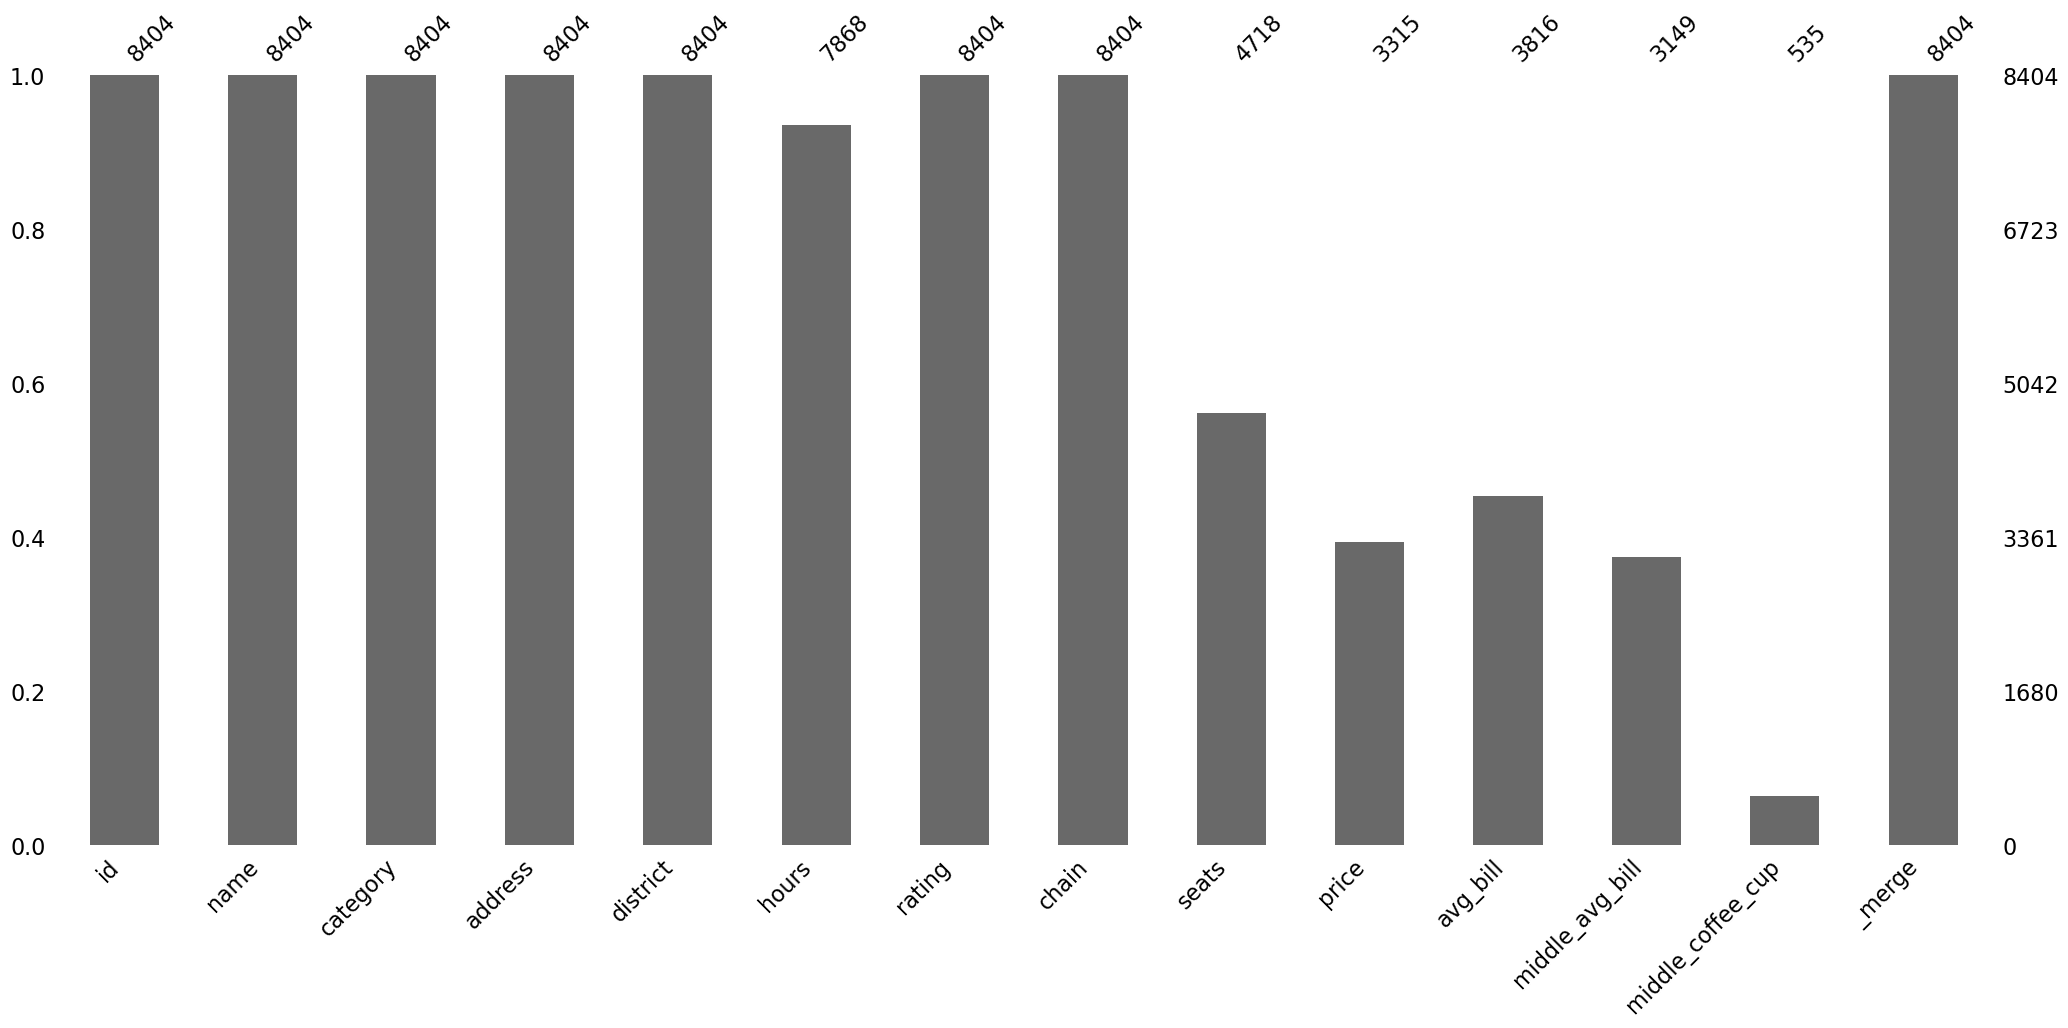

In [31]:
try:
    import missingno as msno
except ImportError:
    !pip install missingno
    import missingno as msno
    
msno.bar(cleaned_df)

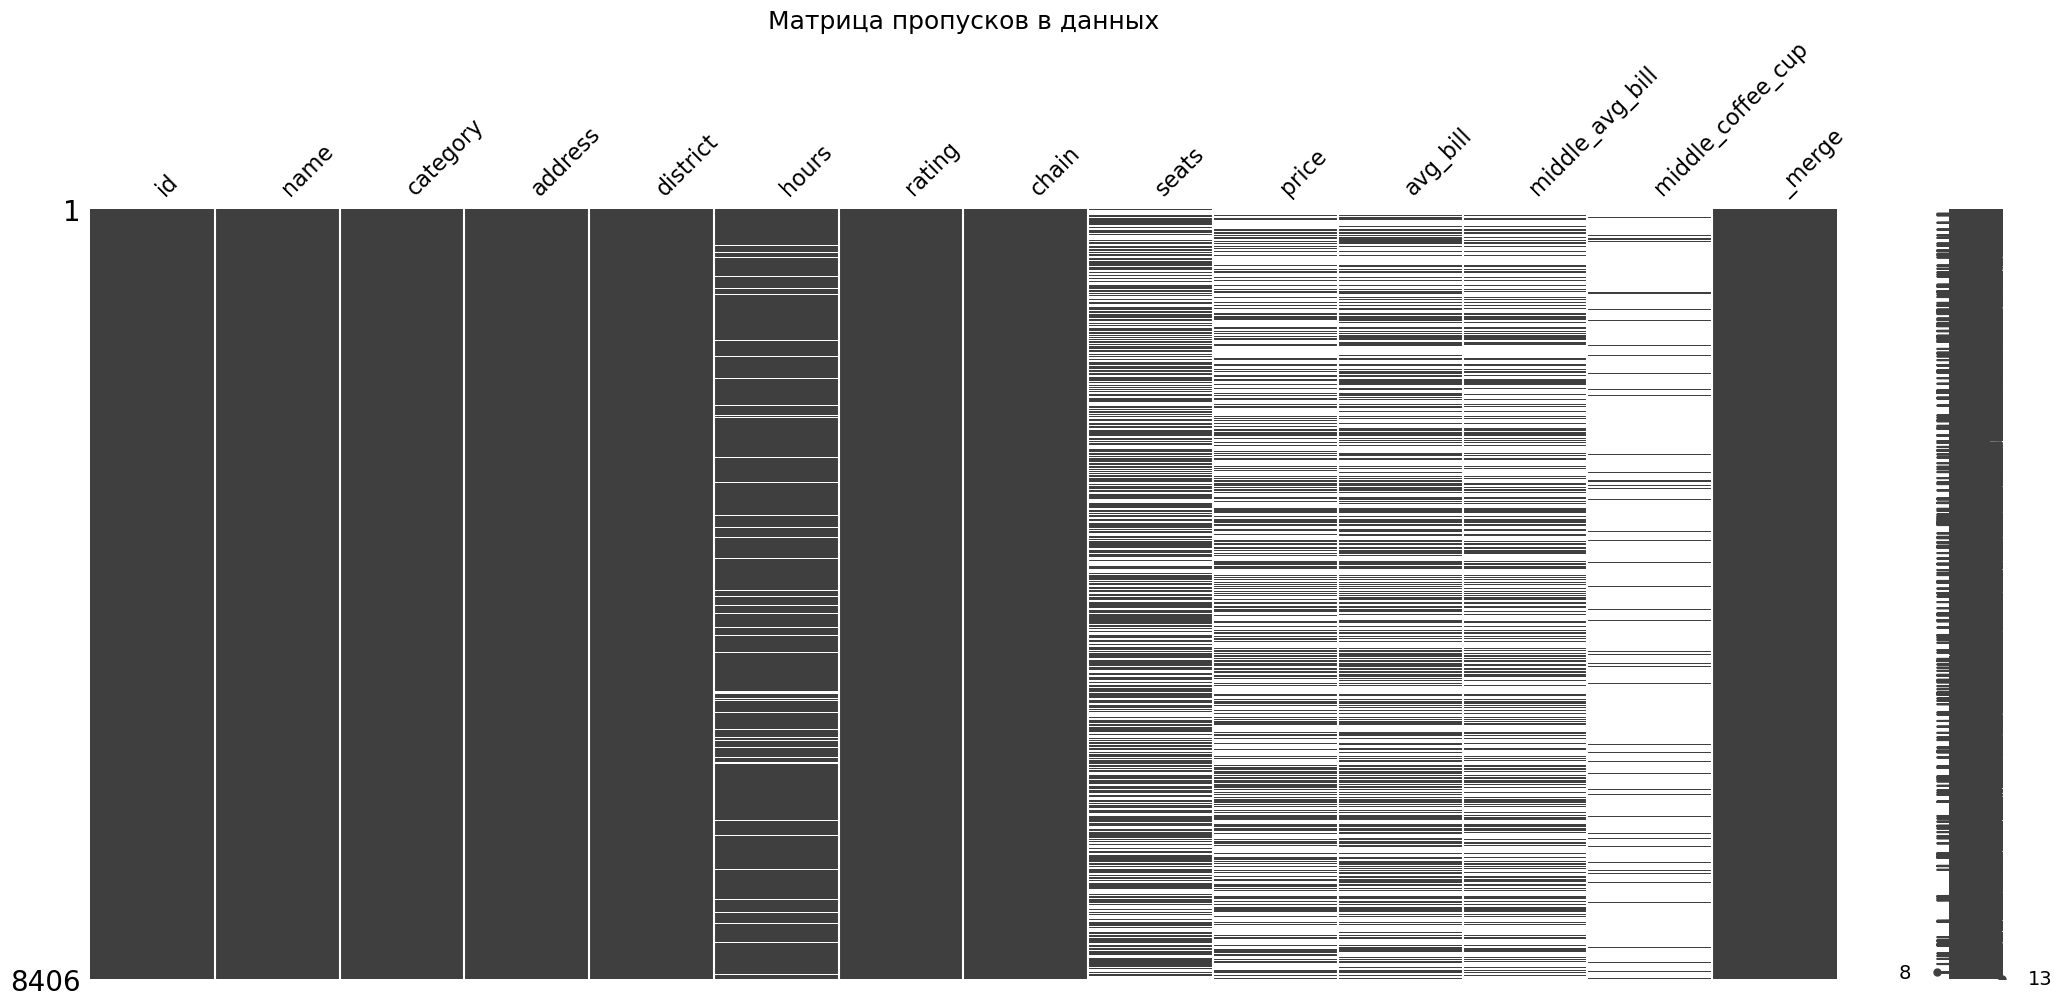

In [32]:
msno.matrix(df)
plt.title('Матрица пропусков в данных', fontsize=18)
plt.show()

Пропуски содержатся в 6 столбцах из 13:

- Наибольшее количество пропусков наблюдается в столбце `middle_coffee_cup` - 7869, что составляет 93,6% всех строк. Такое количество пропусков может быть связано с разными факторами: не для всех категорий заведений актуальны цены на кофе (например для баров и пабов или пиццерии), данные могут быть просто не заполнены или произошла ошибка при импорте, если в поле `avg_bill` для указания были использованы наименования, которые на соответствовали требованиям. Стоит дополнительно проверить информацию в столбце `avg_bill`, на предмет возможности восстановить данные. При отсутствии возможности восстановить данные стоит оставить пропуски как есть, так как удаление или замена такого большого количества строк приведет к значительным искажениям или потери информации и по другим столбцам, которые понадобятся для последующего анализа (например: распределение типов заведений и районов).

  
- На втором месте по количеству пропусков столбец `middle_avg_bill` - 5255 (62,5%). Такое количество пропусков может быть связано с некорректным указанием информации в поле `avg_bill` или отсутствием информации в источниках данных, например заведение достаточно новое и эту информацию еще не заполнили. Можно попробовать восстановить данные проверив корректность записей по полю `avg_bill`. Если восстановить невозможно, то отсутствующие данные оставить без изменений, чтобы не исказить расчетные данные за счет заполнения средними значениями и при этом не потерять информацию по другим столбцам при удалении строк.


- В поле `price` 5089 пропусков (60,6%), что тоже достаточно большой процент. Отсутствие информации может быть связано с тем, что данных просто нет (заведение новое, нет информации о ценах, соответственно невозможно категоризировать заведение по типу цен). В данном случае при таком большом количестве пропусков заполнять отсутствующие значения модой аналогичных групп заведений может привести к искажению данных. Пропуски оставляем, для анализа используем только доступные данные.


- Столбец `avg_bill` содержит 4588 (54,6%). Пропуски могут быть связаны с отсутствием информации в источнике, а также некорректной выгрузкой данных. Поле носит описательный характер (например «Средний счёт: 1000–1500 ₽») и скорее служило как источник для выгрузки данных в столбцы `middle_coffee_cup` и `avg_bill`, а восстановить данные на основе имеющейся информации невозможно, то пропуски оставляем без изменений.


- В поле `seats` 3686 пропусков (43,9%). Пропусков также значительное количество, кроме того оно увеличилось за счет замены некорректных чрезмерно высоких значений на этапе обработки значений-индикаторов и ошибочных значений. Стоит проверить распределение пропусков по разным типам заведений, ценовой категории и району. Если в некоторых группах будет небольшое количество пропуском их можно заполнить медианными значениями для аналогичной группы, но если пропусков много, то стоит оставить группу без изменений, так как замена большего количества значений средними слишком сильно исказит последующие анализы данных.


- В поле `hours` отсутствует 536 значений (6,4%), что достаточно немного, учитывая, что это поле имеет описательную информацию, а для анализа нам понадобится только информаци круглосуточное ли заведение или нет, то сначала стоит создать столбец `is_24_7` и пропуски в новом столбце заполнить исходя из значения моды в группе похожих заведение (тип, район и ценовая категория).

In [33]:
# Создадим колонку для обозначения круглосуточной работы
cleaned_df['is_24_7'] = np.where(
    cleaned_df['hours'].str.strip() == 'ежедневно, круглосуточно', 
    1, 
    np.where(cleaned_df['hours'].notna(), 0, np.nan)
)

# Проверим сколько круглосуточных заведений получилось 
print(f"Всего круглосуточных заведений {cleaned_df['is_24_7'].mean()*100:.2f}%")

Всего круглосуточных заведений 9.28%


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3503202991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned_df['is_24_7'] = np.where(


Напишем функцию для расчета доли пропусков по различным категориям

In [34]:
def nan_share_definition(slice_col, target_col):
    print(f'Распределение доли NaN значений в {target_col} в разрезе {slice_col}')
    # Вычисляем долю пропусков
    report = cleaned_df[target_col].isna().groupby(cleaned_df[slice_col]).mean().sort_values(ascending=False)
    print(report)
    
    
    # Отобразим распределение на графике
    plt.figure(figsize=(10, 5))
    report.plot(kind='bar', 
                title=f'Доля пропусков в {target_col} по {slice_col}', 
                rot=45,
                legend=False)
    
    plt.xlabel(f'Группировка по: {slice_col}')
    plt.ylabel('Доля пропусков')
    plt.show()

Проверим наличие пропусков в разных разрезах

Распределение доли NaN значений в seats в разрезе category
category
кафе               0.505259
столовая           0.492063
кофейня            0.470630
быстрое питание    0.422886
булочная           0.421875
бар,паб            0.393464
ресторан           0.388834
пиццерия           0.327014
Name: seats, dtype: float64


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3417394261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = cleaned_df[target_col].isna().groupby(cleaned_df[slice_col]).mean().sort_values(ascending=False)


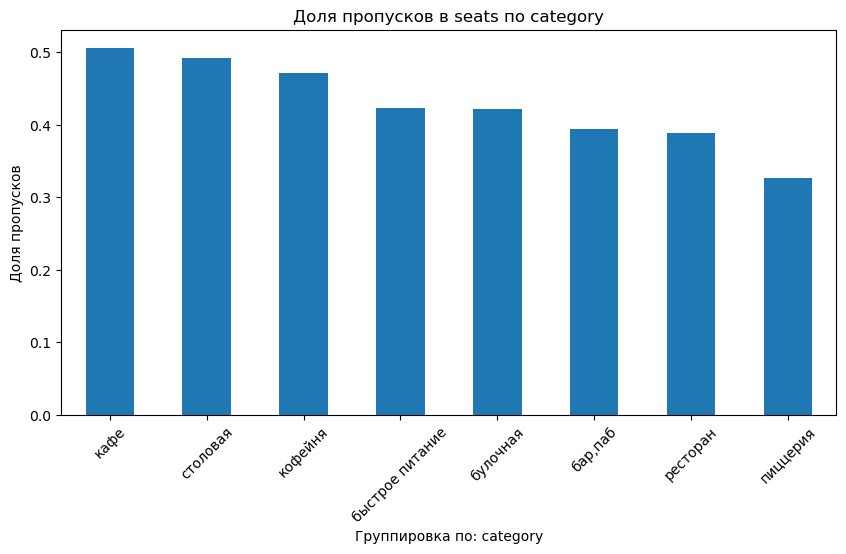

Распределение доли NaN значений в seats в разрезе district
district
юго-восточный административный округ       0.523810
восточный административный округ           0.497494
центральный административный округ         0.474576
западный административный округ            0.452409
северо-восточный административный округ    0.442200
южный административный округ               0.382287
юго-западный административный округ        0.372355
северо-западный административный округ     0.366748
северный административный округ            0.353007
Name: seats, dtype: float64


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3417394261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = cleaned_df[target_col].isna().groupby(cleaned_df[slice_col]).mean().sort_values(ascending=False)


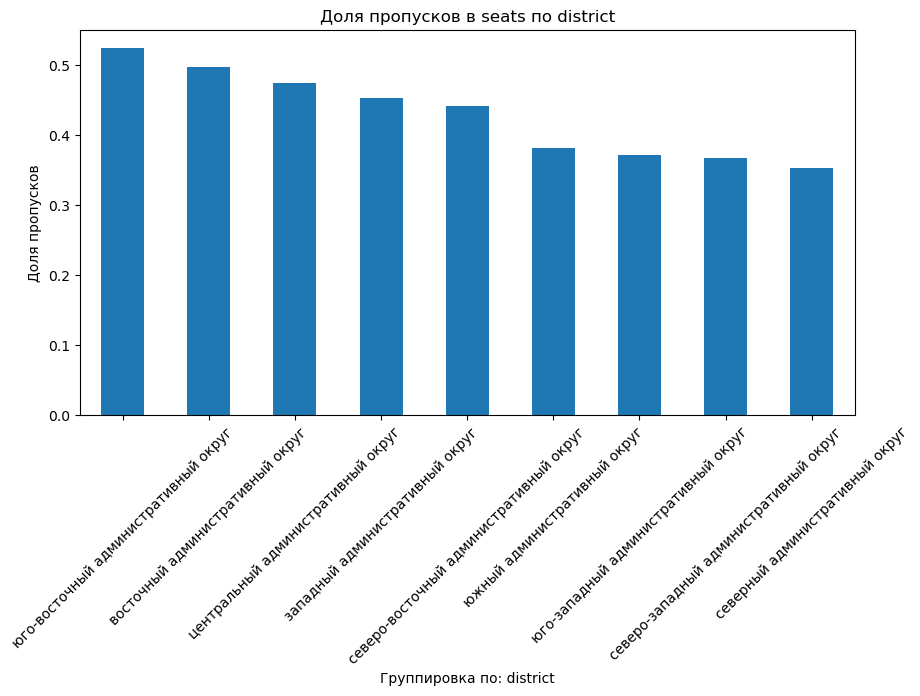

Распределение доли NaN значений в seats в разрезе price
price
средние          0.397733
низкие           0.378205
выше среднего    0.368794
высокие          0.336820
Name: seats, dtype: float64


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3417394261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = cleaned_df[target_col].isna().groupby(cleaned_df[slice_col]).mean().sort_values(ascending=False)


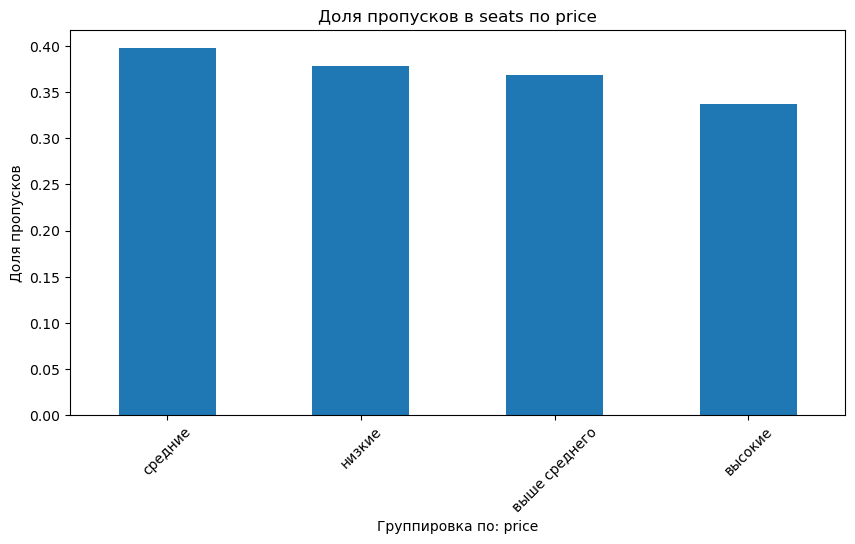

In [35]:
slice_cols = ['category', 'district', 'price']

# Проверим распределение пропусков в колонке seats ы разных разрезах
for col in slice_cols:
    nan_share_definition(col, 'seats')

Все пропуски в колонке `seats` в разных разрезах распределяются достаточно равномерно, от 33% до 50%, в данном случае нет смысла заполнять пропуски, так как даже 33% пропусков заполненных медианными значениями исказят анализ.

_____

Проверим распределение пропусков по вновь созданному столбцу `is_24_7`

Распределение доли NaN значений в is_24_7 в разрезе category
category
кафе               0.157762
быстрое питание    0.054726
ресторан           0.036239
столовая           0.028571
булочная           0.027344
бар,паб            0.023529
кофейня            0.010616
пиццерия           0.007899
Name: is_24_7, dtype: float64


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3417394261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = cleaned_df[target_col].isna().groupby(cleaned_df[slice_col]).mean().sort_values(ascending=False)


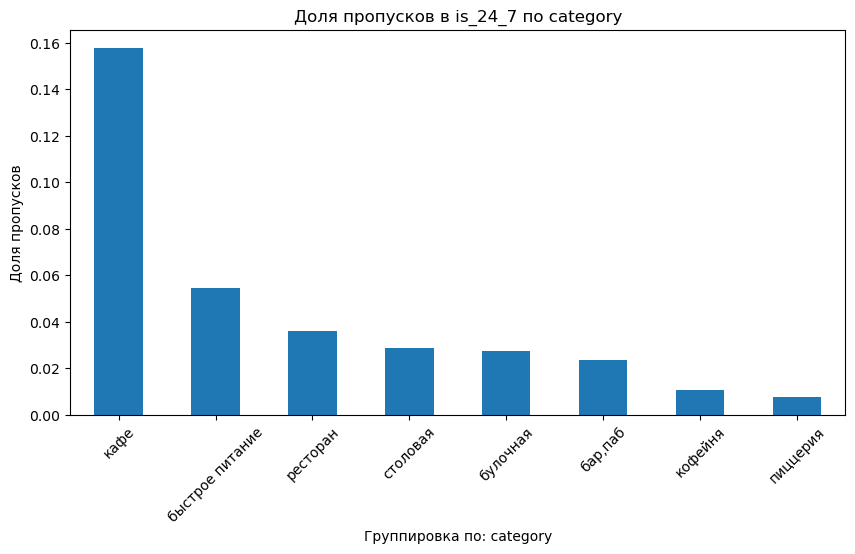

Распределение доли NaN значений в is_24_7 в разрезе district
district
юго-восточный административный округ       0.119048
северо-западный административный округ     0.097800
восточный административный округ           0.093985
юго-западный административный округ        0.083216
западный административный округ            0.077556
южный административный округ               0.072870
северо-восточный административный округ    0.068462
северный административный округ            0.060134
центральный административный округ         0.013827
Name: is_24_7, dtype: float64


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3417394261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = cleaned_df[target_col].isna().groupby(cleaned_df[slice_col]).mean().sort_values(ascending=False)


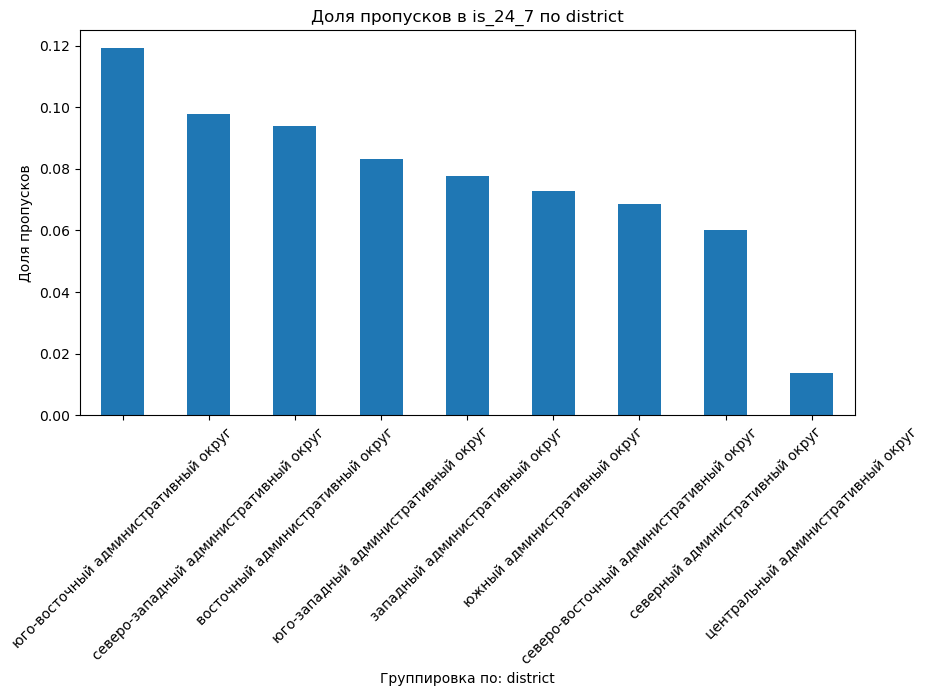

Распределение доли NaN значений в is_24_7 в разрезе price
price
средние          0.002362
высокие          0.000000
выше среднего    0.000000
низкие           0.000000
Name: is_24_7, dtype: float64


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3417394261.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  report = cleaned_df[target_col].isna().groupby(cleaned_df[slice_col]).mean().sort_values(ascending=False)


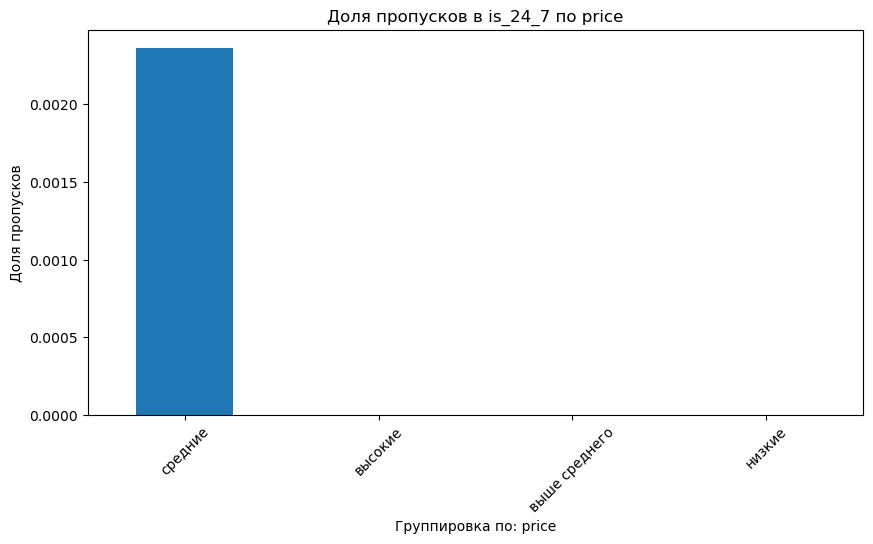

In [36]:
# Проверим распределение пропусков в колонке is_24_7 в разных разрезах
for col in slice_cols:
    nan_share_definition(col, 'is_24_7')

Распределение пропусков по графику работы в разрезе категорий заведений варьируется сильно: больше всего пропусков в кафе - 15.7% Во всех остальных категориях 5,5% и меньше процентов. С точки зрения районов, то распределение следующее, начиная с 11,9% и с постепенным уменьшением. Если рассматривать разрез категории цен, то все пропуски только в средней ценовой категории (менее 1%).

Если учесть все факторы:
- несколько неравномерное распределение пропущенных значений в разных категориях заведений и в разных районах
- всего круглосуточных заведений менее 10%
- особенность круглосуточного режима работы как скорее исключение

То пропуски в данном полу стоит оставить без изменений, так как мода скорее всего для всех категорий будет 0 и тем самым мы исказим долю круглосуточных заведений.

_____

Проверим, есть ли в столбце `avg_bill` данные о цене кружки капучино, которые можно восстановить,

In [37]:
# Макска для фильтрации пустых значений в поле средней стоимоти чашки кофе и строк, где есть вождение слова капучино
string_mask = (
    cleaned_df['middle_coffee_cup'].isna() & 
    cleaned_df['avg_bill'].str.contains('капучино', na=False, case=False)
)

# Посмотрим, что удалось найти
print(cleaned_df[string_mask]['avg_bill'].unique())

[]


Строк с информацией о стоимости капучино для строк в пропущенными средними ценами нет.

--

Проведем аналогичную проверку по среднему чеку
    

In [38]:
# Макска для фильтрации 
string_mask = (
    cleaned_df['middle_avg_bill'].isna() & 
    cleaned_df['avg_bill'].str.contains('средний счёт', na=False, case=False)
)

# Посмотрим, что удалось найти
print(cleaned_df[string_mask]['avg_bill'].unique())

[]


Строк для восстановления данных по среднему счету также нет.

**Промежуточные выводы**

В ходе предобработки были проанализированы пропуски в 6 ключевых столбцах: `middle_coffee_cup`, `middle_avg_bill`, `price`, `avg_bill`, `seats`, `hours` 
По результатам исследования принято решение оставить пропуски без изменений по следующим причинам:

1. Критический объем отсутствующих данных:

В столбцах `middle_coffee_cup` (93.6%) и `middle_avg_bill` (62.5%) доля пропусков слишком высока. Попытка восстановить их через текстовый поиск в avg_bill не дала системных результатов. Заполнение таких объемов медианой или модой создало бы "статистический шум", подменяя реальные рыночные показатели искусственными пиками.

2. Риск искажения структуры (Bias):

В столбце `price` (60.6%) пропуски распределены неравномерно. Заполнение их модой автоматически занизило бы вариативность данных, так как мода чаще всего соответствует одному сегменту.

Для столбца `is_24_7` (график работы) пропуски также оставлены как NaN. Поскольку круглосуточный режим — это редкое исключение (менее 10%), автоматическое заполнение нулями ("не круглосуточно") исказило бы итоговую пропорцию таких заведений в Москве.

3. Репрезентативность имеющихся данных:

Проверки (в разрезе районов и категорий) показали, что пропуски в количестве мест (`seats`) распределены достаточно равномерно. Это позволяет рассматривать строки с заполненными значениями как качественную репрезентативную выборку, не прибегая к рискованному заполнению.

4. Сохранение ценности датасета:

Удаление строк с пропусками привело бы к потере до 90% данных, что сделало бы невозможным анализ по другим важным критериям (география, типы заведений).

**Итог**: Данные оставлены в исходном виде для обеспечения честности и чистоты последующего статистического анализа.


<a id="#3_column_analysis"></a>
## Анализ столбцов данных

### Бинарные признаки и категориальные данные

Проверим распределение заведений общественного питания по категориям (столбец `category`), району (столбец `district`), количество сетевых и несетевых заведений  (столбец `chain`) в целом, а также распределение в зависимости от категории заведения, как распределяются заведения по ценовому сегменту (столбец `price`), какая доля заведений работает круглосуточно, а какая нет (столбец `is_24_7`).

Дополнительно проверим распределение категорий заведений в Центральном административном округе Москвы.

____

Для расчета и визуализации распределений создадим функцию.

In [39]:
# Создадим функцию для расчета распределения и его визуализации 
def get_value_distribution(df, target_column):
    # Считаем распределение
    data = df[target_column].value_counts().sort_values(ascending=False)
    data_share = df[target_column].value_counts(normalize=True).sort_values(ascending=False)
    print(f'Распределение заведений по столбцу {target_column}')
    print(data)
    print()
    print(f'Распределение доли заведений по столбцу {target_column}')
    print(data_share)
    
    # Строим визуализацию
    plt.figure(figsize=(10, 5))
    
    data_share.plot(kind='bar',
             rot=60,
             title=f'Распределение заведений по столбцу {target_column}')
    
    plt.xlabel(target_column)
    plt.ylabel('Доля заведений')
    plt.grid()
    plt.show() 

Проверим распределение по столбцу `category`

Распределение заведений по столбцу category
category
кафе               2377
ресторан           2042
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: count, dtype: int64

Распределение доли заведений по столбцу category
category
кафе               0.282842
ресторан           0.242980
кофейня            0.168134
бар,паб            0.091028
пиццерия           0.075321
быстрое питание    0.071752
столовая           0.037482
булочная           0.030462
Name: proportion, dtype: float64


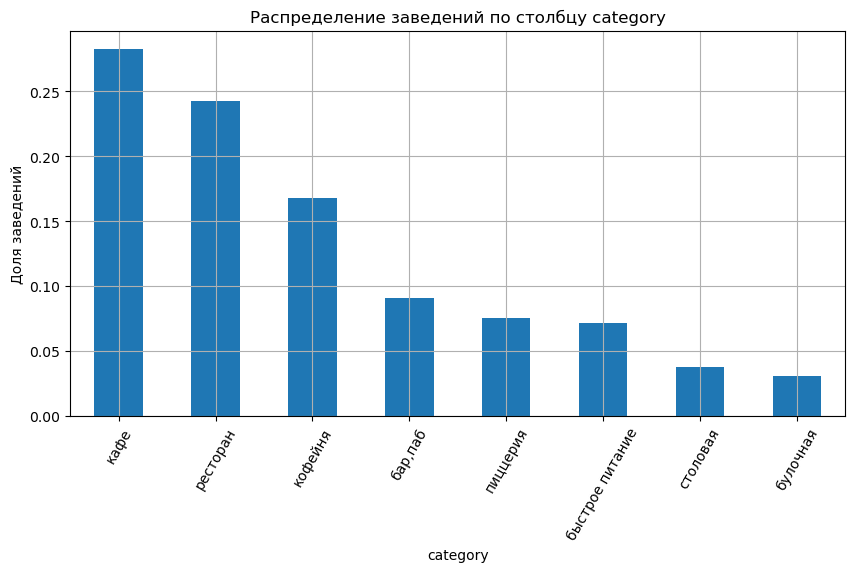

In [40]:
get_value_distribution(cleaned_df, 'category')

Самая большая доля заведений – это **кафе** (28,3%) их в Москве 2377, на втором месте с небольшим отрывом **ресторан** 24,3% - 2042 заведений, на третьем месте **кофейня** (16,8%) 1413 заведений.  Заведения с типом бар/паб, пиццерия и быстрое питание имеют доли от 9,1% до 7,1%. Наименее популярны столовые 3,7% (315 заведений) и булочная 3% (256 заведений).  

Стоит отметить, что всего две категории кафе и рестораны в сумме занимают чуть больше половины рынка. 

Такое распределение выглядит достаточно логичным, так как кафе и рестораны могут быть более универсальным выбором и иметь более широкий ассортимент еды. Это в свою очередь позволяет выбирать такие заведения для компаний с разными вкусами в еде.

___

Проверим распределение по районам.

Распределение заведений по столбцу district
district
центральный административный округ         2242
северный административный округ             898
южный административный округ                892
северо-восточный административный округ     891
западный административный округ             851
восточный административный округ            798
юго-восточный административный округ        714
юго-западный административный округ         709
северо-западный административный округ      409
Name: count, dtype: int64

Распределение доли заведений по столбцу district
district
центральный административный округ         0.266778
северный административный округ            0.106854
южный административный округ               0.106140
северо-восточный административный округ    0.106021
западный административный округ            0.101261
восточный административный округ           0.094955
юго-восточный административный округ       0.084960
юго-западный административный округ        0.084365
северо-западны

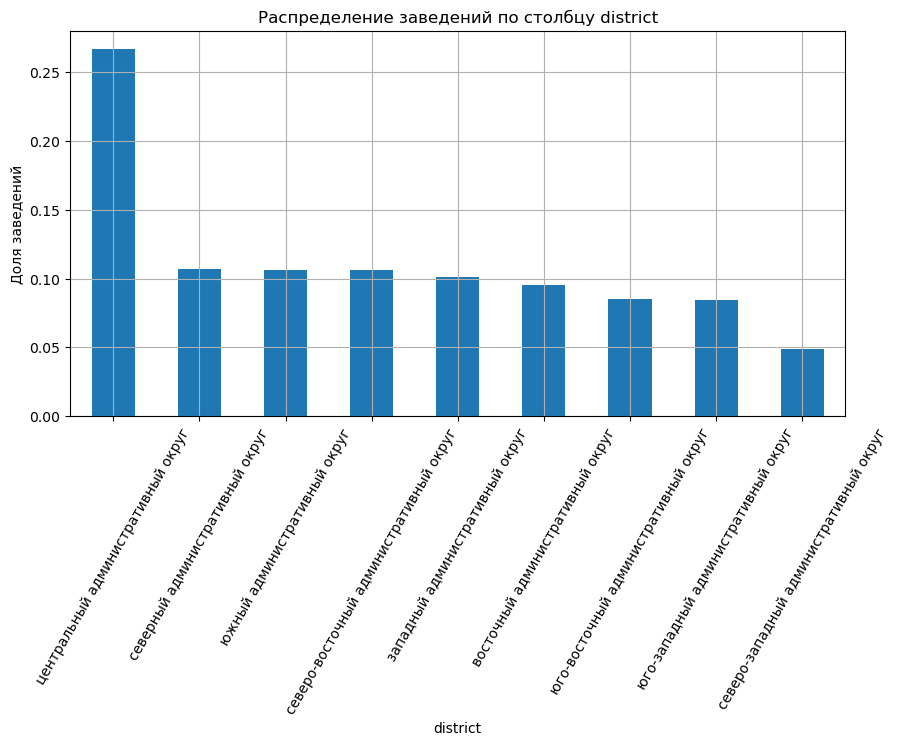

In [41]:
get_value_distribution(cleaned_df, 'district')

Наибольшая доля заведений с большим отрывом сосредоточены в **Центральном административном округе** – 26,7% (), а наименьшее количество заведений в **Северо-западном административном округе** - 4,9% (409 заведений). Заведения в остальных округах распределены более равномерно от 8,4% и до 10,6%.

Такая закономерность не случайна, так как центральный район привлекает не только местных жителей и людей, работающих в центральном районе, но и туристов и людей приехавших в командировки. При этом остальные районы имеют местные заведения, так как из-за больших расстояний не каждый житель готов выезжать из своего района ради похода в заведение.

Интересно, что несмотря на примерно равную площадь остальных округов в северо-западном округе заведений почти в 2 раза меньше, чем в сравнимых округах. Такая особенность может быть связана с особенностями географии (например много парков и лесов), численностью население (оа может быть сильно меньше, чем в соседних округах), а также финансовым состояние округа (услуги заведений не так востребованы как в других районах), а также пол и возраст населения (у людей разного возраста могут быть разные привычки в отношении походов в заведения). 

Для большего понимания такого распределения можно дополнительно проверить распределение численности населения, средние доходы на жителей районов, а также половозрастную структуру населения.

____

Дополнительно проверим распределение разных категорий заведений в **Центральном административном округе**

Распределение заведений в ЦАО

Распределение заведений по столбцу category
category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: count, dtype: int64

Распределение доли заведений по столбцу category
category
ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: proportion, dtype: float64


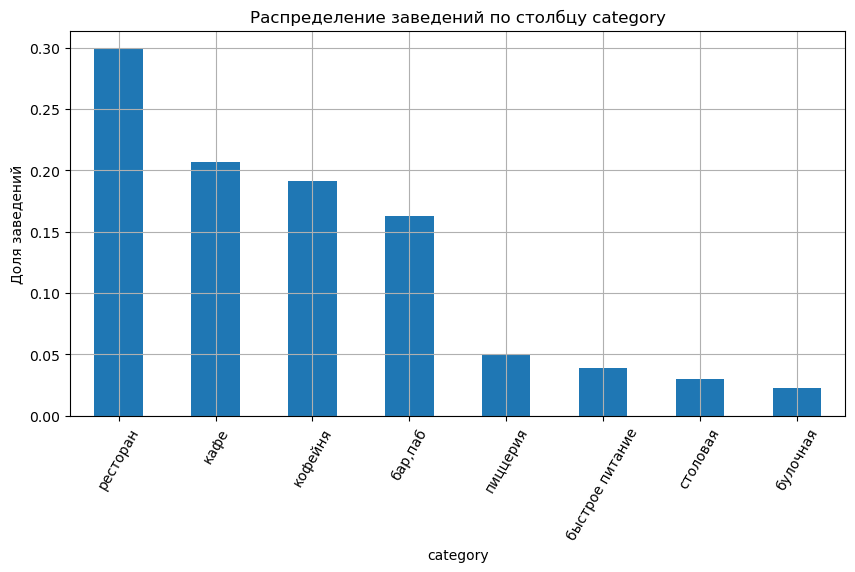

In [42]:
# Отфильтруем данные только для целевого региона
cao_df = cleaned_df.loc[cleaned_df['district'] == 'центральный административный округ']


# Вызываем функцию
print('Распределение заведений в ЦАО')
print()
get_value_distribution(cao_df, 'category')


Если рассматривать распределение категорий заведений только в Центральном административном округе, то стоит отметить, что первые и последние места совпадают, что и для всей Москвы, но доли отличаются. В ЦАО 29,9% заведений – это **рестораны** (670 заведении), 20,7% – **кафе** (464 заведений) и 19%  **кофейни** (428 заведений). Что касается остальных типов заведений, то доля заведений быстрого питания в ЦАО немного выше, чем в среднем по Москве 9,4% против 7,2%. Доли баров/пабов в ЦАО выше, чем во всей Москве: доля баров в ЦАО 16,2% против 9,2%.

Таким образом можно предположить, что в центральном районе большая доля широкоспециализированных заведений типа рестораны и кафе (в сумме около 60% рынка), а также варианты перекуса в виде кофейни либо бары/пабы, что в целом логично, учитывая гипотезу о том, что в основном в центре работают, проводят деловые встречи либо посещают достопримечательности.

___

Проверим распределение по столбцу `chain`.

Распределение заведений по столбцу chain
chain
0    5199
1    3205
Name: count, dtype: Int64

Распределение доли заведений по столбцу chain
chain
0    0.618634
1    0.381366
Name: proportion, dtype: Float64


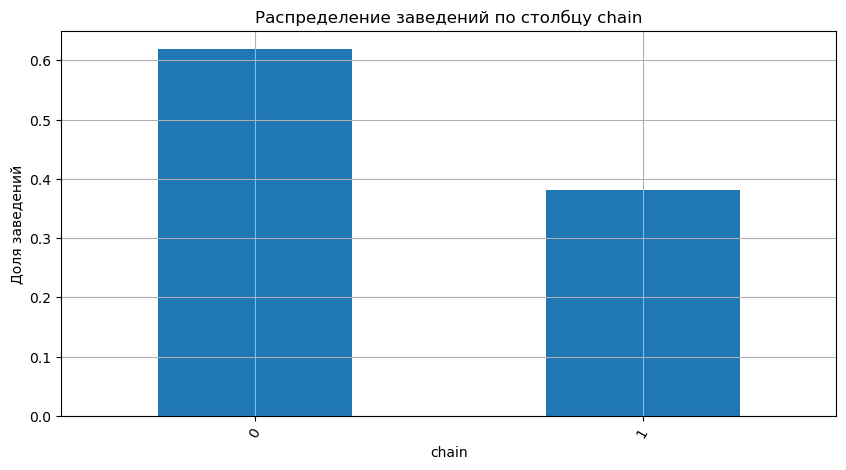

In [43]:
get_value_distribution(cleaned_df, 'chain')

Среди всех заведений **несетевых** 5199 (61,9%), сетевых заведений в Москве 3205, что составляет 38,1%. Можно сделать вывод, что в городе достаточно большое количество сетевых заведений. Проверим дополнительно какие топовые сети по количеству заведений представлено в Москве.

In [44]:
# Отфильтруем заведения по признаку сетевое
print('ТОП-15 сетей по количество заведений')
cleaned_df.loc[cleaned_df['chain'] == 1, 'name'].value_counts().sort_values(ascending=False).head(15)

ТОП-15 сетей по количество заведений


name
шоколадница                            120
домино'с пицца                          76
додо пицца                              74
one price coffee                        71
яндекс лавка                            69
cofix                                   65
prime                                   50
хинкальная                              44
кофепорт                                42
кулинарная лавка братьев караваевых     39
теремок                                 38
чайхана                                 37
cofefest                                32
буханка                                 32
му-му                                   27
Name: count, dtype: int64

Наиболее крупные сети это **Шоколадница** - 120 заведений,  **Домино'с пицца** - 76 заведений и **Додо пицца** - 74.

Можно дополнительно провести анализ распредления крупных, средних и небольних сетевых заведений, в том числе понять используют ли сети одинаковый тип заведений, как распредлеются по районам города.

Дополнительно проверим как распределяются сетевые заведения по типам

/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/392006171.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chain_grouped_df = cleaned_df.groupby('category')['chain'].value_counts(normalize=True).sort_values().unstack()


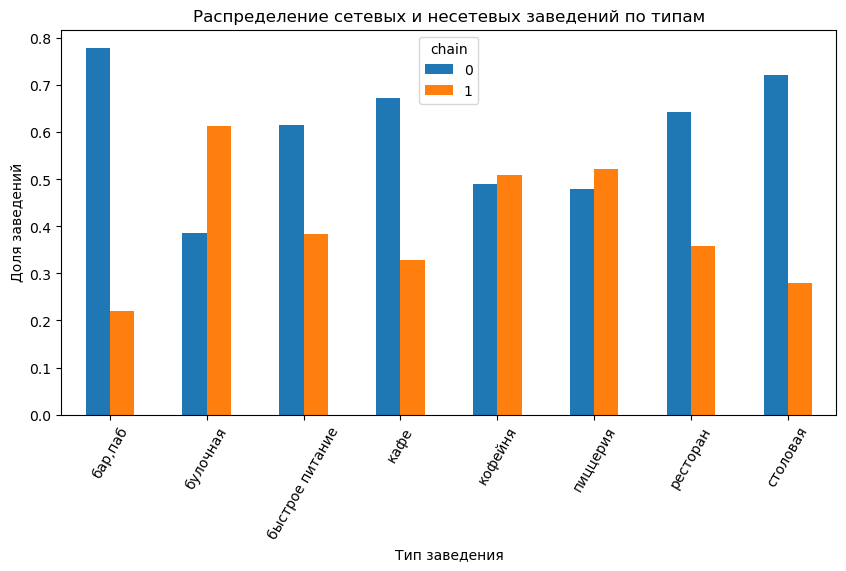

In [45]:
# Сгруппируем данные по полю chain
chain_grouped_df = cleaned_df.groupby('category')['chain'].value_counts(normalize=True).sort_values().unstack()

# Отобразим расперделение на графике


chain_grouped_df.plot(kind='bar',
                     rot=60,
                     title='Распределение сетевых и несетевых заведений по типам',
                     figsize=(10, 5))

plt.xlabel(f'Тип заведения')
plt.ylabel('Доля заведений')
plt.show()

Можно выделить **ТОП** категории, в которых сетевые заведения преобладают: **булочная**, **пиццерия** и **кофейня**. Такой тип заведений имеет в основном более ограниченный ассортимент и количество посадочных мест, поэтому такой бизнес проще масштабировать, но важно сделать оговорку, что доля булочных сетевых и несетевых достаточно мала, как и пиццерий, появление нескольких сетевых заведений может сильно изменить соотношение сетевых и несетевых.

**Антитоп** - **бар/паб**, в этой категории  не сетевых заведений гораздо больше. Похожая ситуация и со **столовыми**, **кафе** и **ресторанами**, что тоже достаточно объяснимо: бары и пабы часто предлагают уникальную атмосферу или авторские напитки, столовые зачастую могут быть привязаны к месте (например бизнес-центр или госучреждение), в ресторанах большой ассортимент блюд - все эти факторы делают масштабирование гораздо более сложной задачей. Если рассматривать большую долю не сетевых заведений в категории **кафе**, то можно предположить, что такое распределение связано с большим разнообразием кафе, от маленьких тематических (веган-кафе), до больших кафе с разными направлениями блюд. При такой ситуации сетевым гигантам сложно занять эту нишу, так как этот сегмент самый популярный и для повышения конкурентоспособности заведения должны больше выделяться.

_____

Проверим распределение по столбцу `price`.

Распределение заведений по столбцу price
price
средние          2117
выше среднего     564
высокие           478
низкие            156
Name: count, dtype: int64

Распределение доли заведений по столбцу price
price
средние          0.638612
выше среднего    0.170136
высокие          0.144193
низкие           0.047059
Name: proportion, dtype: float64


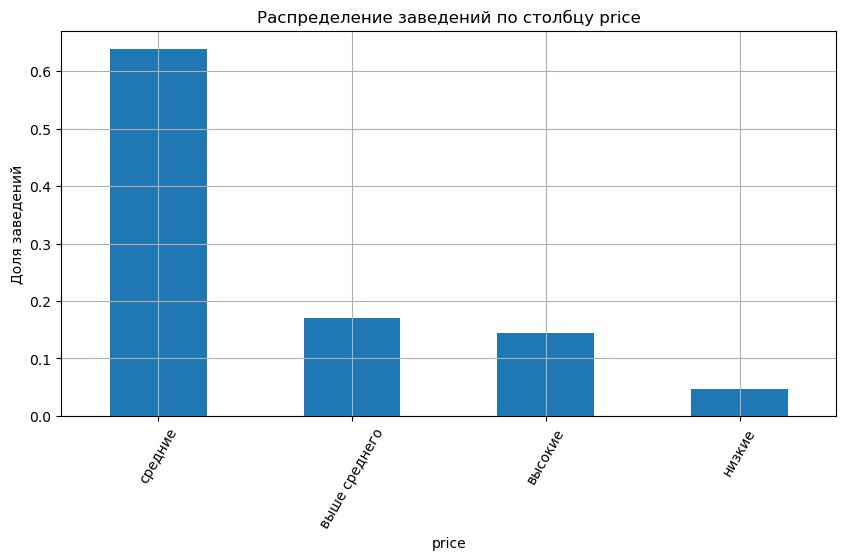

In [46]:
get_value_distribution(cleaned_df, 'price')

Самое большое количество заведений с ценами в категории «средние» - 2117 (63,9%), на втором месте заведения «выше среднего» - 564 (17%), потом «высокие» - 478 (14,4%), а меньше всего заведений «низком» ценовом сегменте - их всего 156 (4,7%). 
Можно предположить, что в основном кафе и рестораны также будут иметь «средний» ценовой сегмент.

Дополнительно проверим в каких ценовых диапазонах в основном представлена наиболее встречаемые типы заведений: кафе и рестораны.

Распределение ценовых категорий для кафе
Распределение заведений по столбцу price
price
средние          499
выше среднего     78
высокие           30
низкие            26
Name: count, dtype: int64

Распределение доли заведений по столбцу price
price
средние          0.788310
выше среднего    0.123223
высокие          0.047393
низкие           0.041074
Name: proportion, dtype: float64


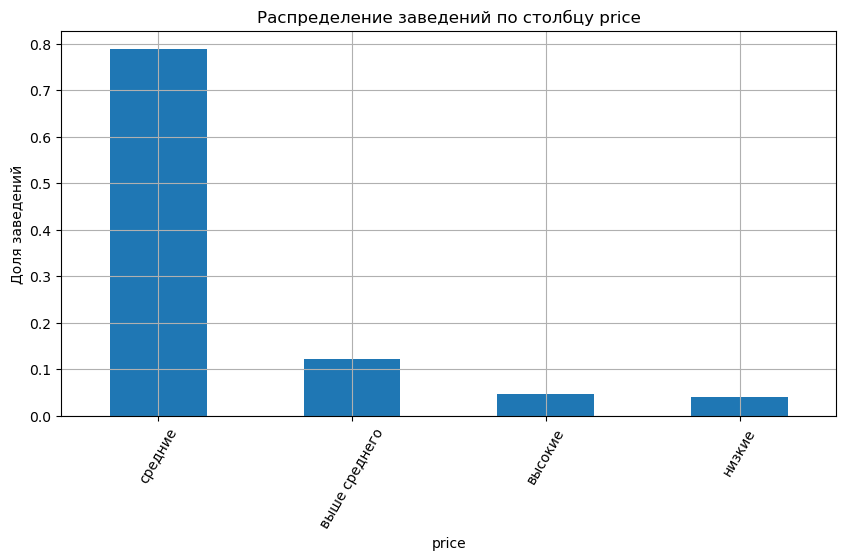


Распределение ценовых категорий для ресторан
Распределение заведений по столбцу price
price
средние          458
высокие          270
выше среднего    268
низкие            21
Name: count, dtype: int64

Распределение доли заведений по столбцу price
price
средние          0.450344
высокие          0.265487
выше среднего    0.263520
низкие           0.020649
Name: proportion, dtype: float64


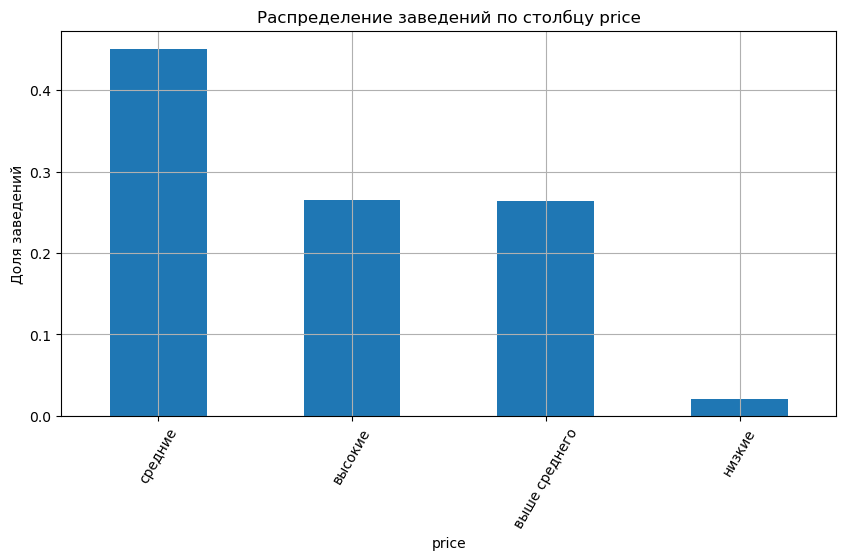

In [47]:
for mask in ['кафе', 'ресторан']:
    new_df = cleaned_df.loc[cleaned_df['category'] == mask]
    print(f'Распределение ценовых категорий для {mask}')
    get_value_distribution(new_df, 'price')
    print()

Если рассматривать заведения с типом **кафе**, то подавляющее большинство  заведений имеют «средний» ценовой диапазон - 78,8%, на втором месте с большим отрывом сегмент «выше среднего» - 12,3%. Среди ресторанов также большая доля «среднего» ценового сегмента - 45,5%. Ценовые сегменты «высокий» и «выше среднего» среди ресторанов представлены примерно равными долями чуть более 26%. 

Можно сделать вывод, что позиционирование ресторанов сосредоточено в более премиальном сегменте, в то время как кафе больше ориентируются на средний сегмент.

Дополнительно можно проверить распределение разных ценовых сегментов по районам, чтобы понять как меняются цены с удалением от центра.

___

Проверим распределение заведений  по режиму работы.

Распределение заведений по столбцу is_24_7
is_24_7
0.0    7138
1.0     730
Name: count, dtype: int64

Распределение доли заведений по столбцу is_24_7
is_24_7
0.0    0.907219
1.0    0.092781
Name: proportion, dtype: float64


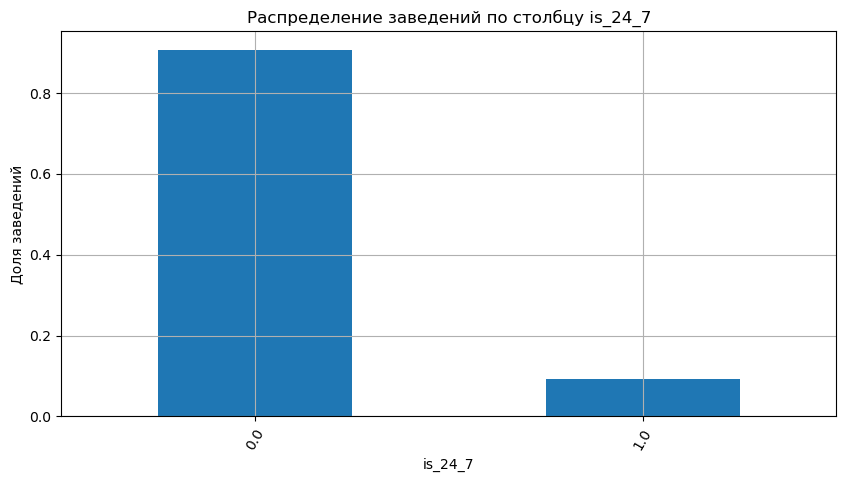

In [48]:
get_value_distribution(cleaned_df, 'is_24_7')

Как и предполагалось, в основном заведения работают по ограниченному графику - 90,7%, в то время как круглосуточно работает только 9,3%. Такое распределение достаточнно логично, так как круглосуточная работа скорее исключение, чем стандартный сервис.

### Непрерывные и дискретные числовые данные 

Проверим распределение заведений в зависимости от рейтинга (столбец `rating`), количества посадочных мест (столбец `seats`), среднего счета (столбец `middle_avg_bill`) и средней стоимости чашки кофе (столбец `middle_coffee_cup`).

___

Для удобства создадим функцию для визуализации распределений

In [49]:
def visualize_distribution(df, target_column, binwidth, hist_ticks_step):
     
    min_val = df[target_column].min()
    max_val = df[target_column].max()
    bins_range = np.arange(min_val, max_val + binwidth, binwidth)
    
    # Гистограма распредления
    df[target_column].plot(kind='hist',
                          rot=60,
                          alpha=0.75,
                          bins=bins_range,
                          edgecolor='black',
                          figsize=(9, 4))

    plt.title(f'Гистограмма распредления значений по столбцу {target_column}')
    plt.xlabel(f'{target_column}')
    plt.ylabel('Количество заведений')
    plt.xticks(bins_range[::hist_ticks_step])
    plt.grid()

    

    # Диаграмма размах
    plt.figure(figsize=(10 ,2))

    sns.boxplot(data=df, x=target_column)

    plt.title(f'Диаграмма размаха значений по столбцу {target_column}')
    plt.xlabel(f'Значения столбца {target_column}')
    plt.xticks(bins_range[::hist_ticks_step], rotation=60)
    plt.grid()
    
    plt.show()

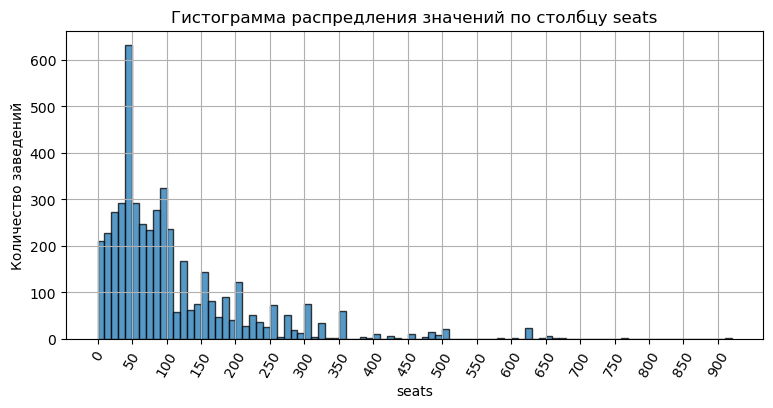

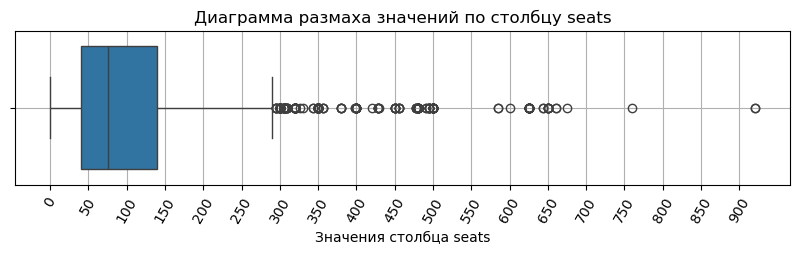

In [50]:
visualize_distribution(cleaned_df, 'seats', 10, 5)

Распределение заведений по количеству мест сильно смещено в левую часть, присутствует большой хвост справа. Тоже самое наблюдается на диаграмме размаха. Основное количество заведений сосредоточено в диапазоне от 40 до 140 мест с пиком заведений на 40-50 мест, медианное значение 75. Также наблюдается достаточное количество заведений без посадочных мест (чуть больше 200). Заведения без посадочных мест скорее всего являются форматами «кофе с собой», «еда на вынос», киоски в парках и аналогичные общепиты.

*При первичной обработке экстремальных значений на этапе «Обработка значений-индикаторов и ошибочных значений» для 16 строк, в которых значения по полю `seats` было выше 1000 произведены замена ны Nan,так как большинство этих заведений находились по одному и тому же адресу было сделано предположение, что вместо данных о посадочных местах конкретного заведения были внесены данных всего фудкорта.*

Не смотря на первичную обработку, в данных по-прежнему наблюдаются выбросы: заведения с количеством мест более 290. Свыше 290 мест начинаются штучные, нестандартные проекты. Нетипично большое количество посадочных мест может быть нормальным для очень крупных заведений, банкетных залов, мест для проведения живых выступлений, небольших фудкортов, но также могут быть и просто ошибочными данными.

Можно сделать вывод, что типичное заведение в Москве рассчитано до 290 посадочных мест, половина заведений имеет до 75 посадочных мест, больше всего заведений организуют от 40 до 140 посадочных мест, но самое популярное количество мест 40-50.

___

Проверим типичное количество посадочных мест для разных категорий заведений. 

Расчет среднего и медианного значений посадочных мест для разных категорий заведени


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/1040611583.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_seats_group_df = cleaned_df.groupby('category')['seats'].agg(['mean', 'median'])


,mean,median
category,,
ресторан,120.06,90.0
"бар,паб",118.21,82.5
кофейня,106.81,80.0
столовая,95.62,78.0
быстрое питание,96.19,65.0
кафе,98.15,60.0
пиццерия,91.69,53.5
булочная,89.39,50.0


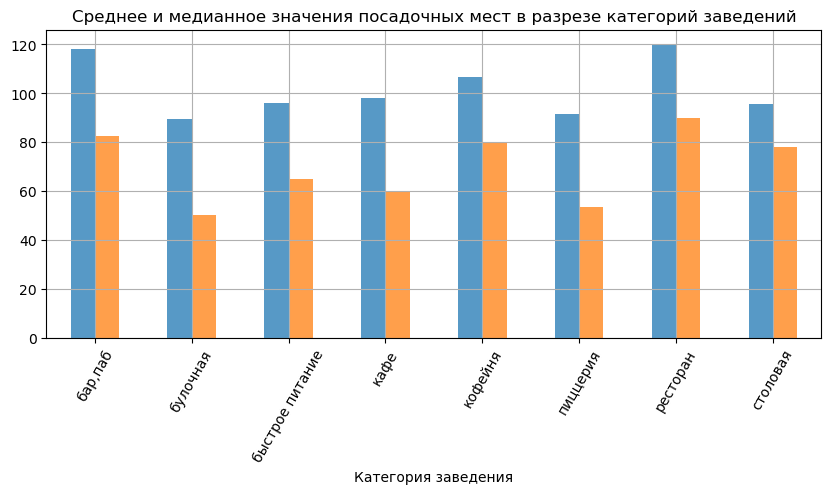

In [51]:
# Сгруппируем данные по типу заведений
category_seats_group_df = cleaned_df.groupby('category')['seats'].agg(['mean', 'median'])
print('Расчет среднего и медианного значений посадочных мест для разных категорий заведени')
display(category_seats_group_df.sort_values('median', ascending=False).astype('float').round(2))

# Визуализируем на графике
category_seats_group_df.plot(kind='bar',
                       alpha=0.75,
                       rot=60,
                       title='Среднее и медианное значения посадочных мест в разрезе категорий заведений',
                       legend=False,
                        figsize=(10,4))

plt.xlabel('Категория заведения')
plt.grid()
plt.show()

Практически для всех категорий среднее значение сильно отличается от медианного, что говорит о наличии выбросов значений количества посадочных мест.  Стоит дополнительно проверить распределение для каждого типа заведений.

Распределение посадочных мест для бар,паб


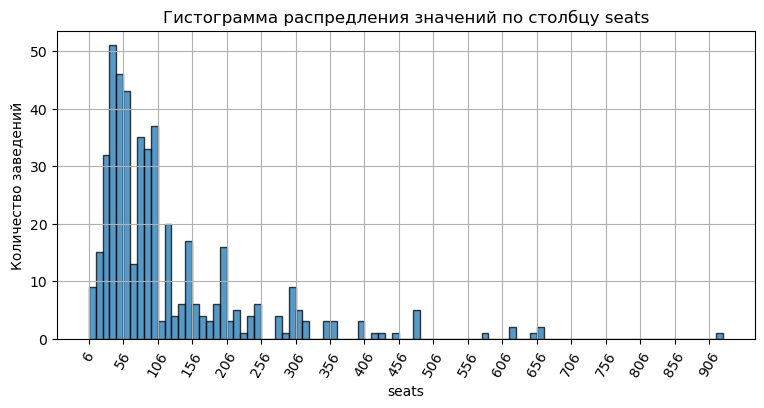

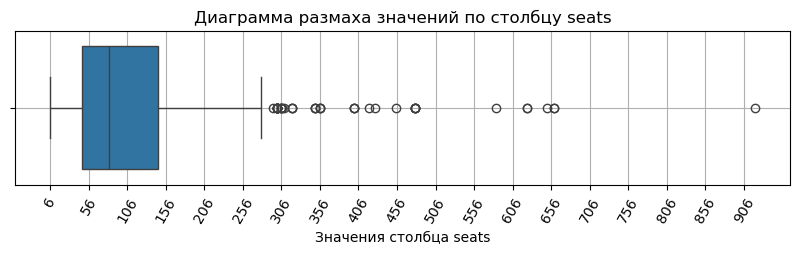


Распределение посадочных мест для кафе


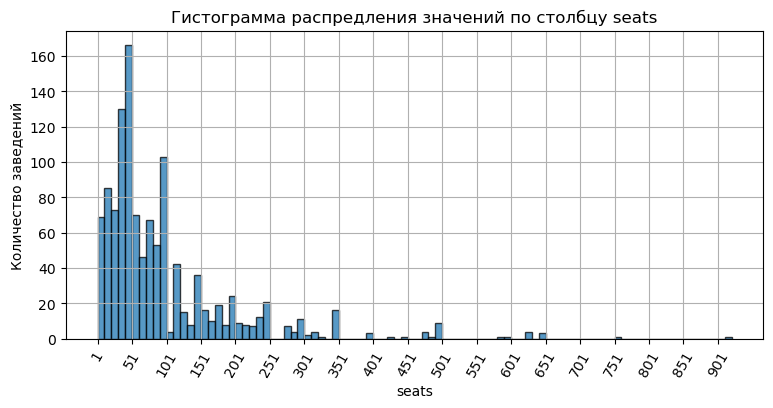

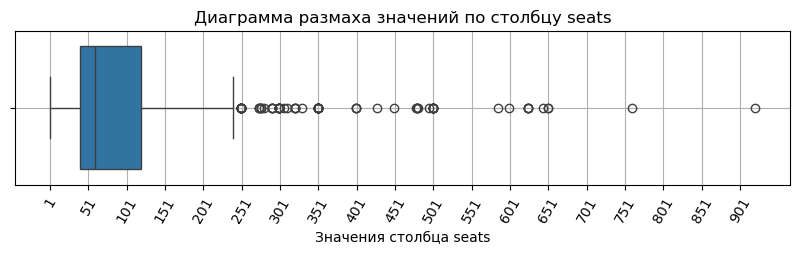


Распределение посадочных мест для ресторан


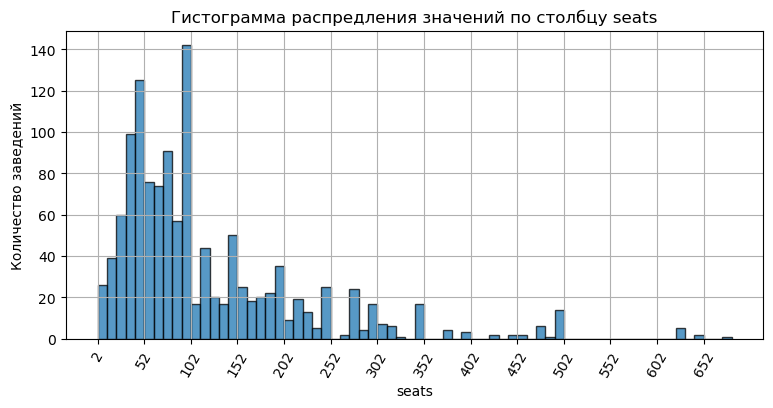

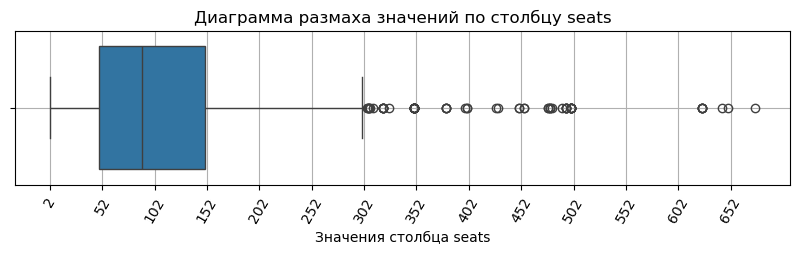


Распределение посадочных мест для кофейня


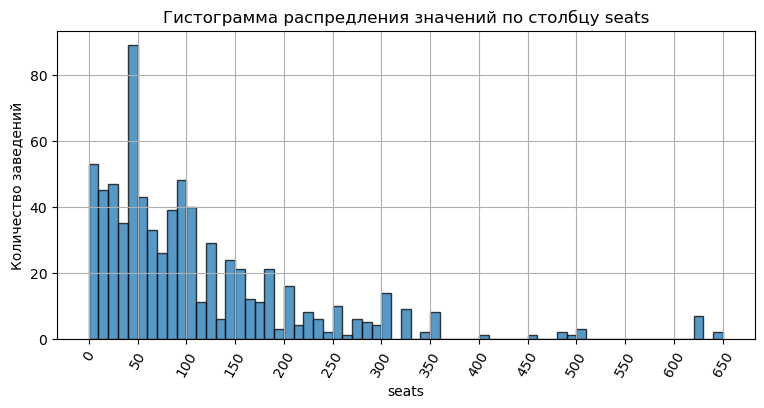

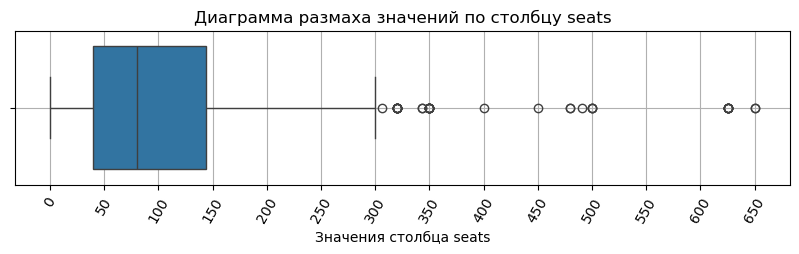


Распределение посадочных мест для булочная


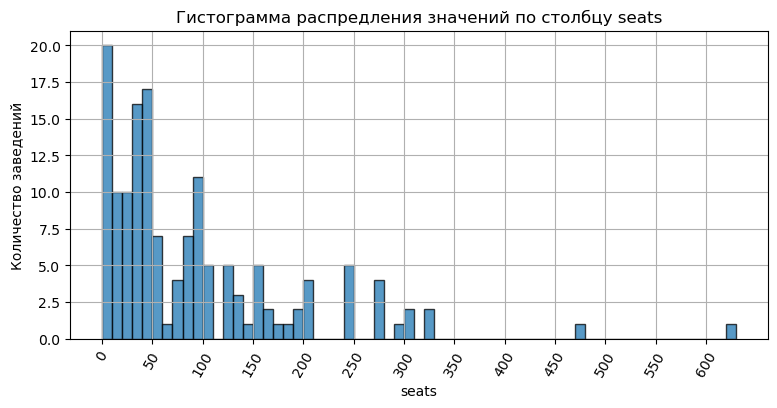

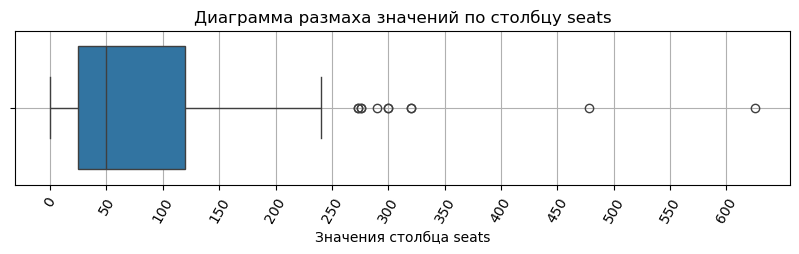


Распределение посадочных мест для пиццерия


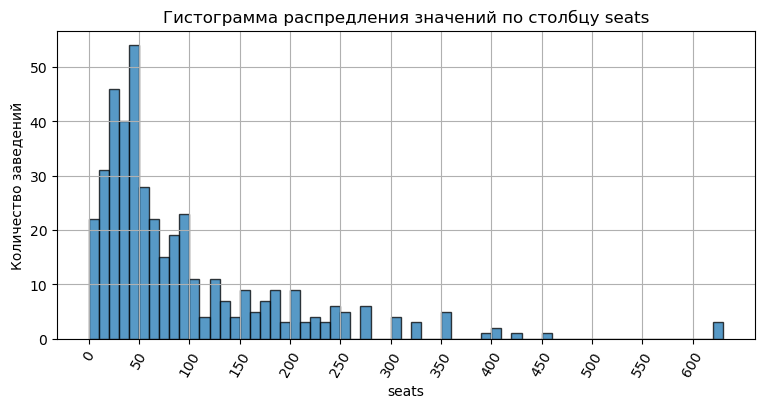

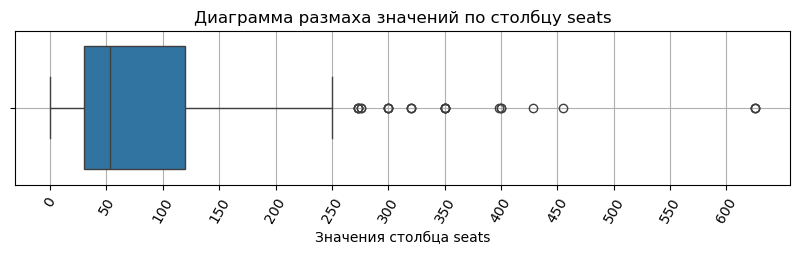


Распределение посадочных мест для быстрое питание


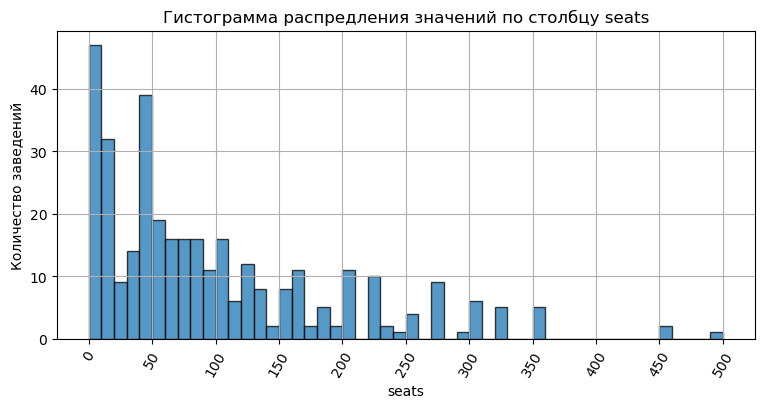

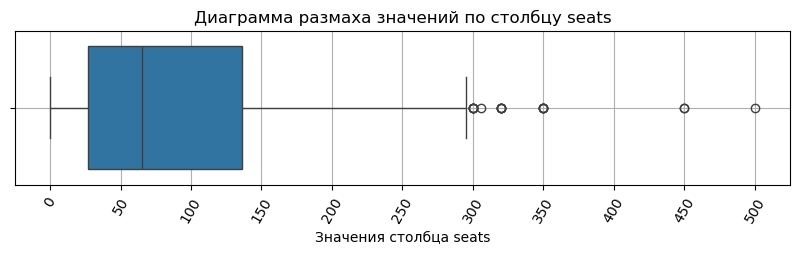


Распределение посадочных мест для столовая


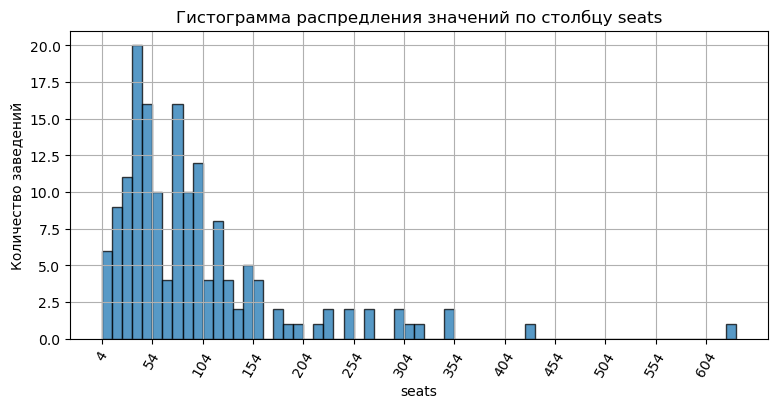

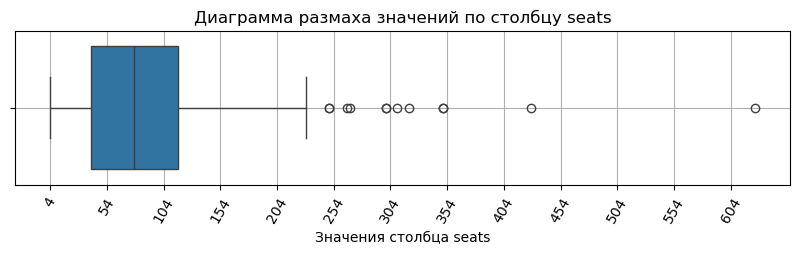

In [52]:
for col in cleaned_df['category'].unique():
    filtered_df = cleaned_df.loc[cleaned_df['category'] == col]
    print(f'Распределение посадочных мест для {col}')
    visualize_distribution(filtered_df, 'seats', 10, 5)
    print()

Гипотеза о наличии выбросов для каждой из категорий подтвердилась. Наибольшие выбросы наблюдаются для заведений: `кафе`  и `бар, паб` (более 900 посадочных мест), такие высокие значения могут быть вызваны либо ошибкой ввода (лишний 0), либо заведение расположено в торговом центре и все посадочные места фудкорта приписали конкретному заведению.


На основании графиков распределения можно наблюдать следующие типичные значения посадочных мест:
- `кафе` 41-51 место
- `ресторан`- 2 пика (моды) 42-52 места или 92-102 места
- `кофейня` - 40-50 мест
- `бар, паб` 36-46 мест
- `пиццерия` - 40-50 мест
- `булочная` - 0 мест, то есть «еда с собой» (скорее всего просто точка продажи выпечки или киоск), второй пик (мода) 40-50 мест
- `быстрое питание` - 0 мест («еда с собой») (скорее всего просто точка продажи выпечки или киоск), второй пик (мода) 40-50 мест.
- `столовая` - 34-44 места

При выборе количества посадочных мест стоит ориентироваться на тип заведения и выбирать соответствующий диапазон.

_____

Проверим распределение рейтинга по заведениям

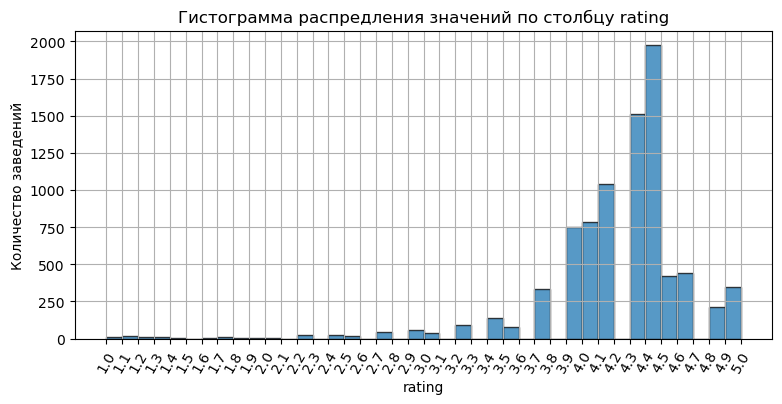

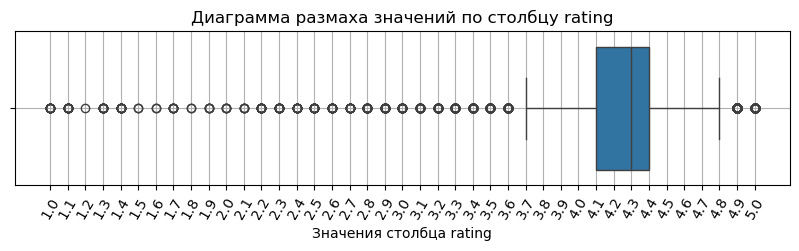

In [53]:
visualize_distribution(cleaned_df, 'rating', 0.1, 1)

Распредление смещено в правую сторону с левым динным хвостом. В среднем рейтинги варьируются от 4.1 и до 4.4, то есть можно сдлеать вывод, что в среднем на рынке представлены заведения с достаточно высоким качеством. Проверим средние и медианные значения для каждой категории заведений.

Расчет среднего и медианного значений рейтингов для разных категорий заведений


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/2200310718.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  categ_rating_group_df = cleaned_df.groupby('category')['rating'].agg(['mean', 'median'])


,mean,median
category,,
"бар,паб",4.4,4.4
булочная,4.3,4.3
кофейня,4.3,4.3
пиццерия,4.3,4.3
ресторан,4.3,4.3
столовая,4.2,4.3
быстрое питание,4.1,4.2
кафе,4.1,4.2


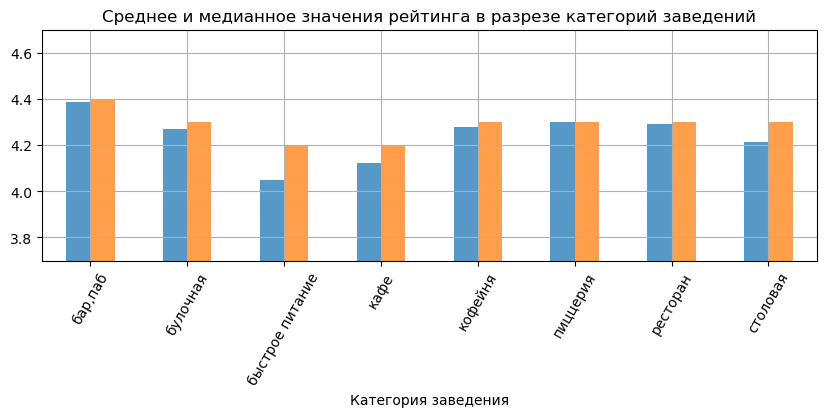

In [54]:
# Сгруппируем данные по типу заведений
categ_rating_group_df = cleaned_df.groupby('category')['rating'].agg(['mean', 'median'])
print('Расчет среднего и медианного значений рейтингов для разных категорий заведений')
display(round(categ_rating_group_df.sort_values('median', ascending=False), 1))

# Визуализируем на графике
categ_rating_group_df.plot(kind='bar',
                       alpha=0.75,
                       rot=60,
                       title='Среднее и медианное значения рейтинга в разрезе категорий заведений',
                       legend=False,
                       figsize=(10,3),
                       ylim=(3.7, 4.7))

plt.xlabel('Категория заведения')
plt.grid()
plt.show()

Если рассматривать средний и медианный рейтинг по категориям, то больших различий нет и они примерно равны, то есть нет слишком больших выбросов, которые бы сильно меняли среднее значение.

Медианный рейтинг варьируется от 4,2 до 4,4, самый низкий рейтинг у заведений типа `кафе` и `быстрое питание`, самый высокий у категории `бар,паб`. То есть заведения всех типов предполагает в среднем высокое качество.

Чуть более высокий рейтинг у заведений типа `бар,паб` может быть связан с более лояльной аудиторией, так как при выборе бара клиент сразу выбирает желаемую тематику и напитки, то есть его ожидания с большей долей вероятности оправдаются, в то время как клиенты приходящие в `кафе` и заведения типа `быстрое питание` могут иметь абсолютно разные представления о сервисе, должном уровне сервиса, а также в такие заведения часто ходит больше людей, что в свою очередь может тоже снижать долю лояльных посетителей.

___
Проверим распределение среднего чека по заведениям


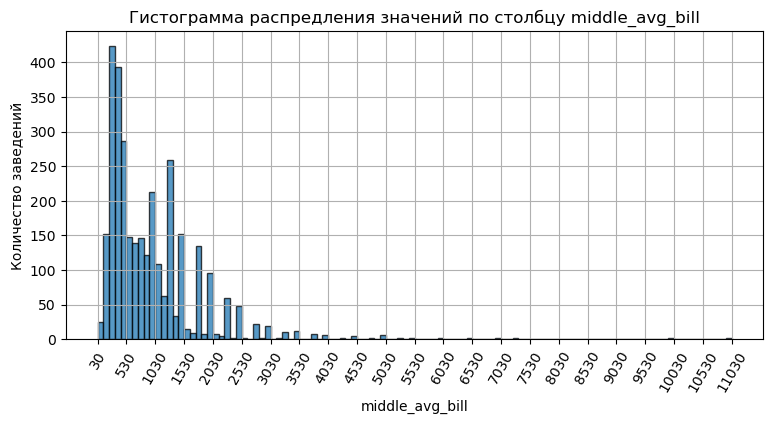

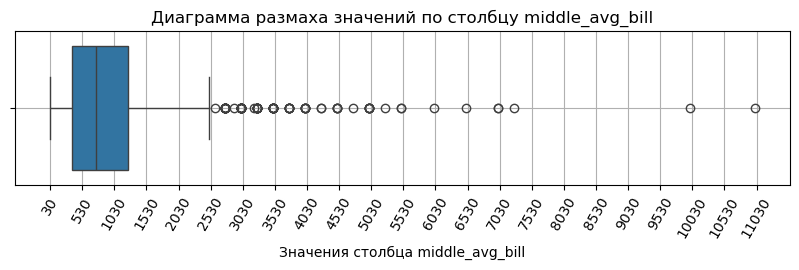

In [55]:
visualize_distribution(cleaned_df, 'middle_avg_bill', 100, 5)

*На этапе Обработки значений-индикаторов и ошибочных значений была проведена замена выброса среднего чека в 35000 на медианное значение аналогичного типа заведения в том же районе с аналогичным ценовым сегментом.*

Распределение среднего чека сильно смещено в левую сторону с большим хвостом справа, не смотря на предварительную обработку в данных по-прежнему наблюдаются выбросы со значением среднего чека выше 10000. Такой средний чек может быть реальным значением, но скорее в уникальном случае с престижным рестораном в центре города.
Основная масса заведений имеет средний чек в диапазоне от 330 до 1230, что соответствует распределению заведений по ценовым категориям: основная массам заведений предлагает услуги в «среднем» ценовом сегменте.

____
Дополнительно проверим распределение среднего чека по разным районам Москвы

Расчет среднего и медианного значений среднего чека для разных районов


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/249148140.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_avg_price_group_df = cleaned_df.groupby('district')['middle_avg_bill'].agg(['mean', 'median'])


,mean,median
district,,
западный административный округ,1053.23,1000.0
центральный административный округ,1192.94,1000.0
северо-западный административный округ,822.22,700.0
северный административный округ,927.96,650.0
юго-западный административный округ,792.56,600.0
восточный административный округ,820.63,575.0
северо-восточный административный округ,716.61,500.0
южный административный округ,730.89,500.0
юго-восточный административный округ,654.10,450.0


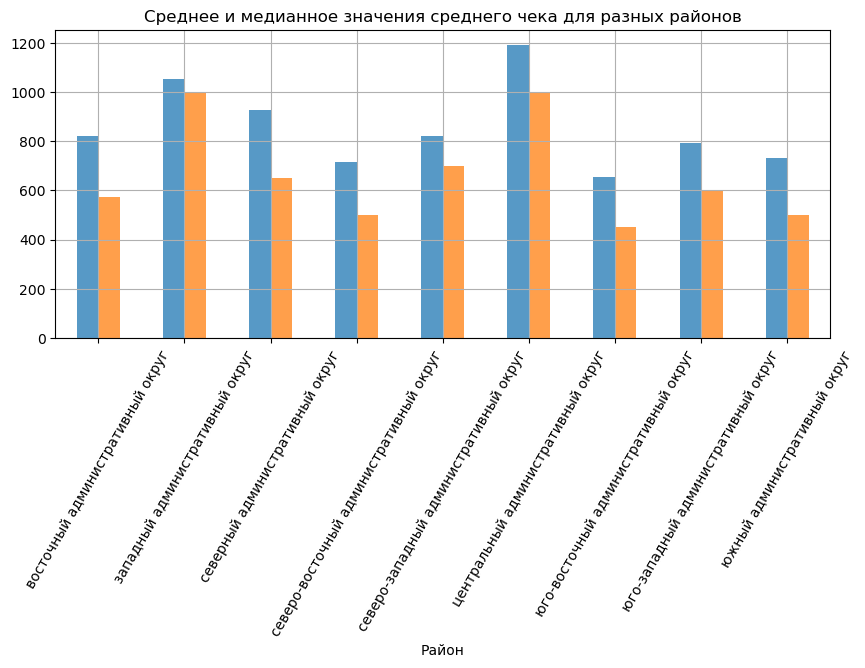

In [56]:
# Сгруппируем данные по району
district_avg_price_group_df = cleaned_df.groupby('district')['middle_avg_bill'].agg(['mean', 'median'])
print('Расчет среднего и медианного значений среднего чека для разных районов')
display(round(district_avg_price_group_df.sort_values('median', ascending=False), 2))

# Визуализируем на графике
district_avg_price_group_df.plot(kind='bar',
                                 alpha=0.75,
                                 rot=60,
                                 title='Среднее и медианное значения среднего чека для разных районов',
                                 legend=False,
                                 figsize=(10,4))

plt.xlabel('Район')
plt.grid()
plt.show()

Средний чек варьируется от 654,1 до 1192,94 рублей, медианный чек варьируется от 450 до 1000 рублей в зависимости от района. Максимальный средний чек в **центральном административном округе** и составляет 1192,9 рубля, минимальный средний чек в **юго-восточном административном округе** и составляет 654,1 рубль. При этом стоит обратить внимание, что для разных районов разница между средним и медианным чеком может также сильно отличаться. Например **центральный административный округ** и **западный административный округ** имеют разные средние значения (1192,94 и 1053,23 рубля соответственно), но одинаковые медианные чеки по 1000 рублей. Если сравнивать еще 2 района **северный административный округ** - средний чек составляет 927,96 рублей, что выше, чем в **северо-западный административный округ**, но при это медианный чек у первого ниже, чем и составляет 650 рублей против 700 рублей. Такая разница между средним и медианным чеком может свидетельствовать о достаточно большой вариативности цен внутри района.

Можно сделать вывод, что средняя цена в **ЦАО** выше, чем в районах удаленных от центра, но важно, что средние цены в нецентральных районах также могут варьироваться почти в 2 раза.

____
Поверим как меняется средний чек для разных районов.

Распределение среднего чека для северо-восточный административный округ


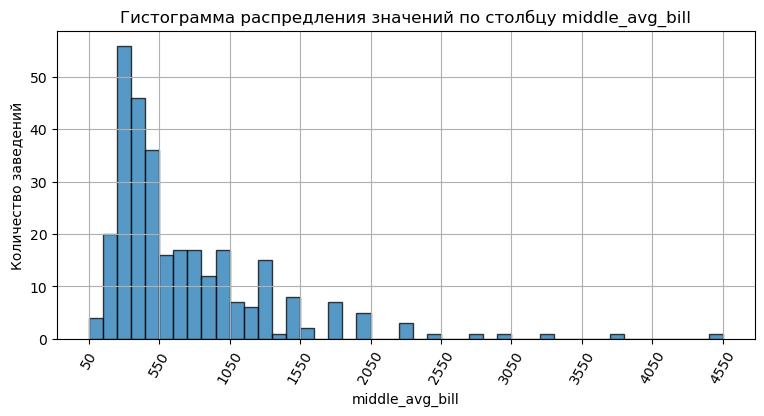

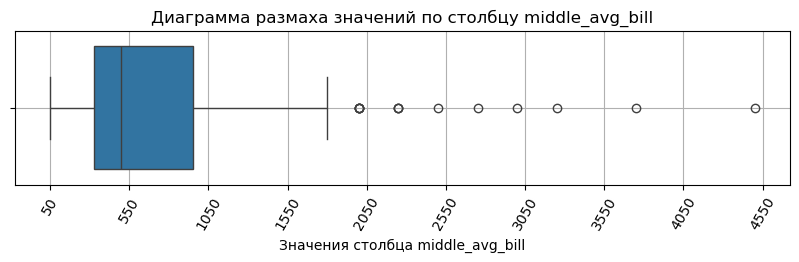


Распределение среднего чека для западный административный округ


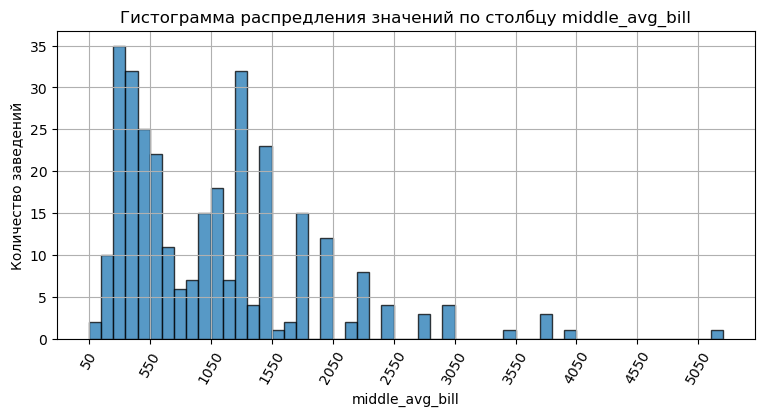

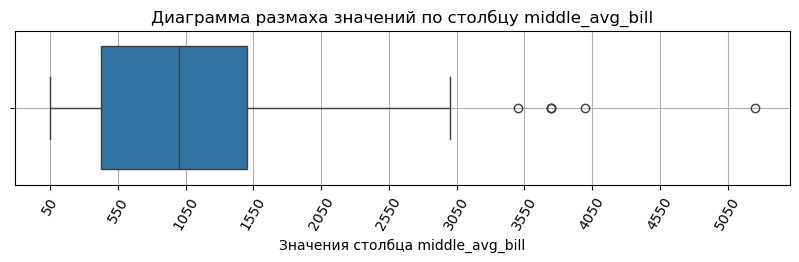


Распределение среднего чека для северный административный округ


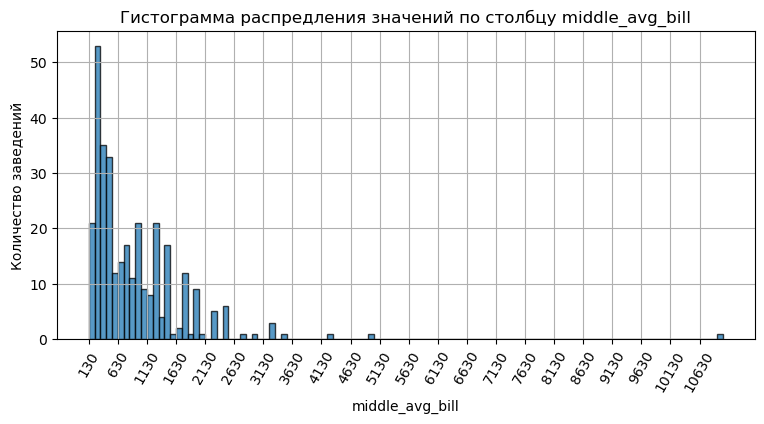

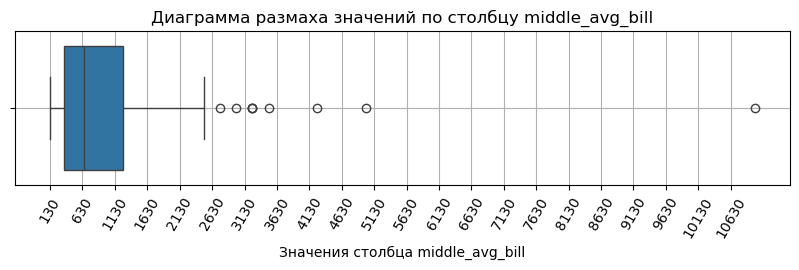


Распределение среднего чека для центральный административный округ


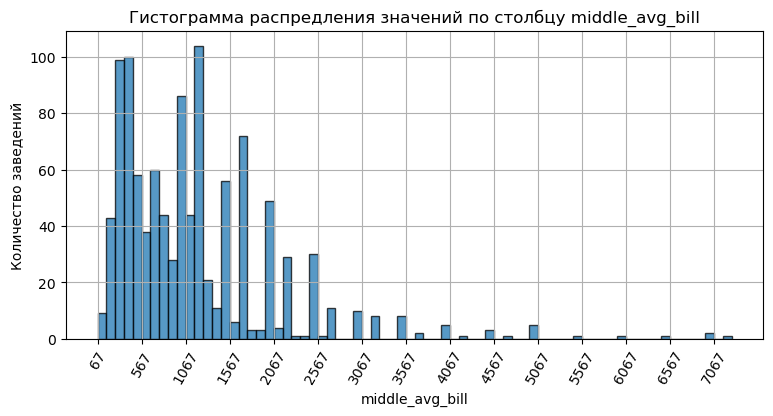

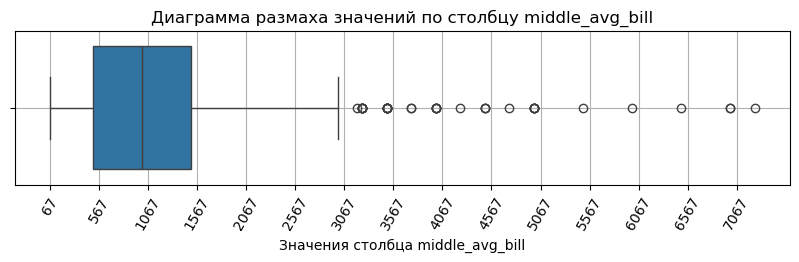


Распределение среднего чека для восточный административный округ


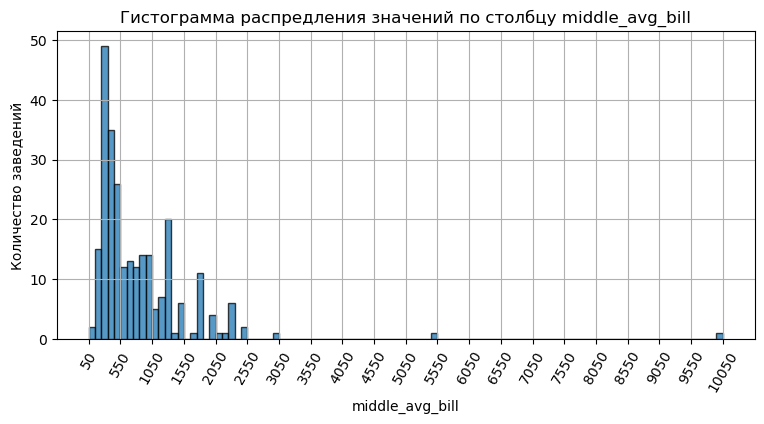

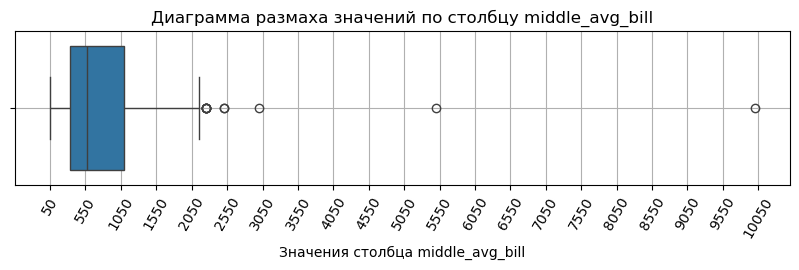


Распределение среднего чека для северо-западный административный округ


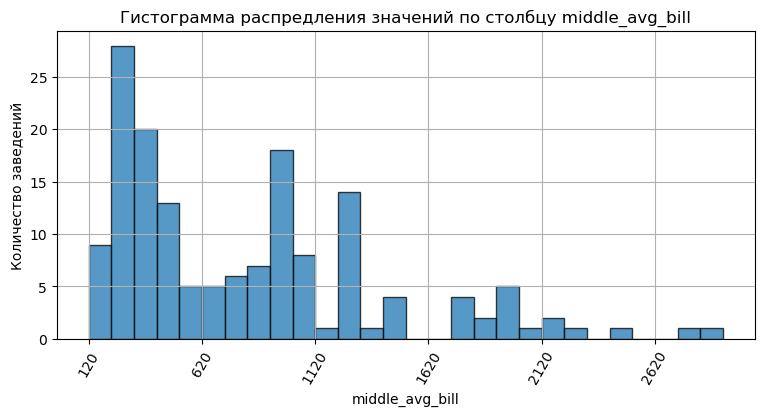

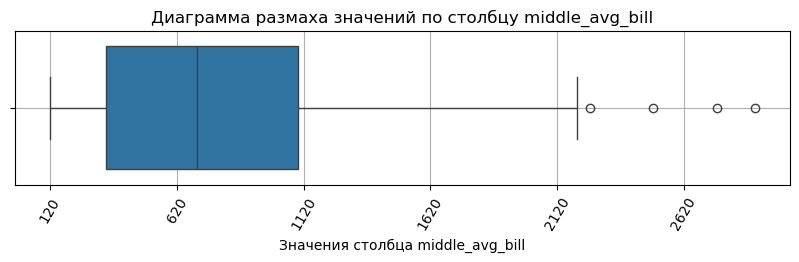


Распределение среднего чека для южный административный округ


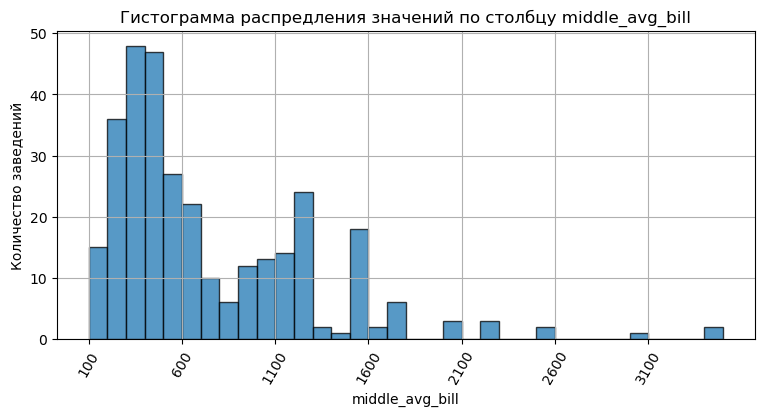

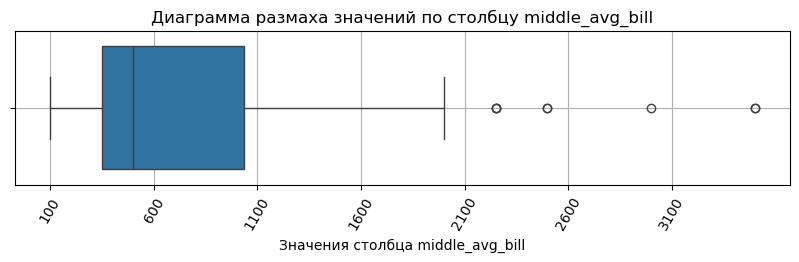


Распределение среднего чека для юго-западный административный округ


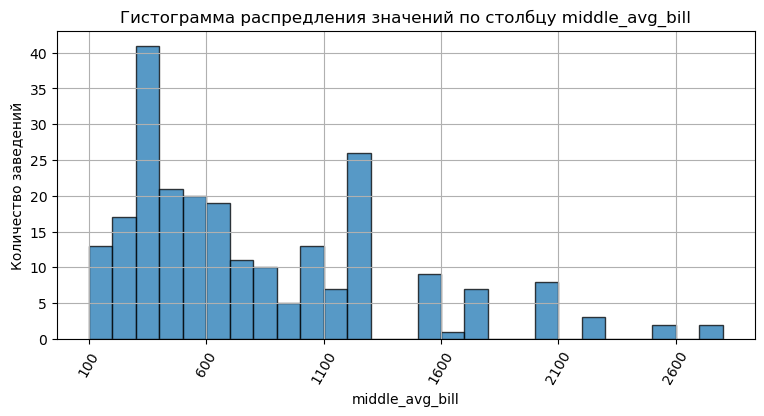

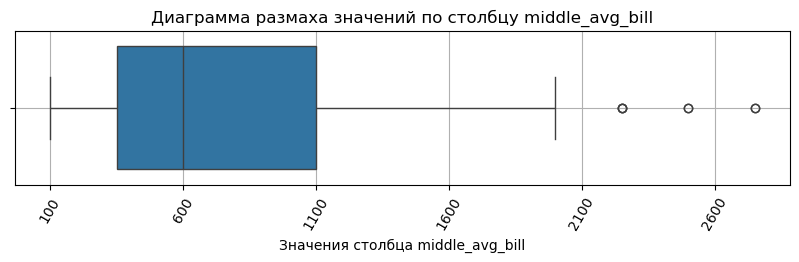


Распределение среднего чека для юго-восточный административный округ


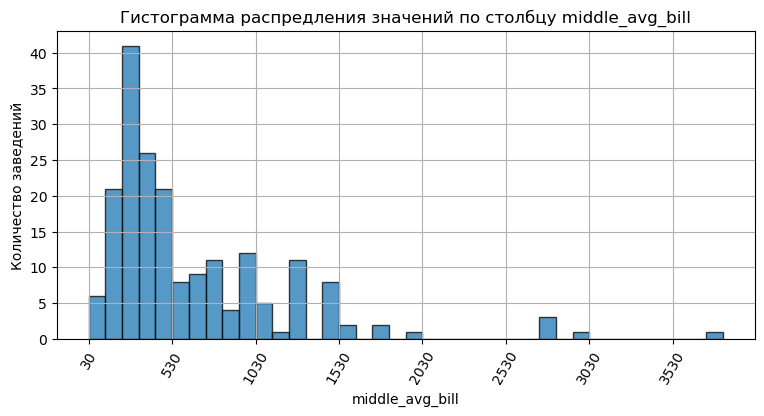

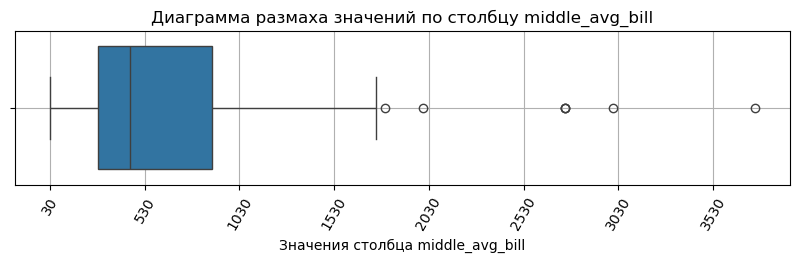

In [57]:
for col in cleaned_df['district'].unique():
    district_filtered_df = cleaned_df.loc[cleaned_df['district'] == col]
    print(f'Распределение среднего чека для {col}')
    visualize_distribution(district_filtered_df, 'middle_avg_bill', 100, 5)
    print()

Гипотеза о наличии выбросов в среднем чеке подтвердилась для многих районов.

Наибольшие выбросы чеки свыше 10000 зафиксированы в следующих районах **северный административный округ**, **восточный административный округ**. 

Наиболее ровное распределение с минимальными выбросами в следующих районах **северо-западный административный округ**, **южный административный округ**, **юго-западный административный округ**, **юго-восточный административный округ**. 

Наиболее типичные значения среднего чека по районам:
- `центральный административный округ` имеет несколько пиковых диапазонов значений: 1167 - 1267 и 267-467 рублей
- `западный административный округ` значения моду в диапазоне 250-350 рублей, но также есть пики в диапазонах 350-450 рублей и 1250-1350 рублей.
- `северо-западный административный округ` - типичный диапазон цен 220-320 рублей
- `северный административный округ` - типичное значение диапазона цен 230-330 рублей
- `юго-западный административный округ` - мода в диапазоне 300-400 рублей
- `восточный административный округ` - пиковый диапазон 350-450 рублей
- `северо-восточный административный округ` мода по цене в диапазон 250-350 рублей
- `южный административный округ`  - мода в диапазоне 300-500 рублей
- `юго-восточный административный округ` - мода в диапазоне 230-330 рублей.

___

**Промежуточный вывод**
В ходе анализа данных по столбцам можно сделать следующие выводы:
1. **Тип заведения:** самые популярные заведения для всего города - это **кафе**, **ресторан** и **кофейня**, наименее популярные - столовые и булочные. 
2. **География:** больше всего заведений сосредоточено в **Центральном административном округе**, а наименьшее к в **Северо-западном административном округе** - 4,9% (409 заведений). ТОП популярных типов заведений в ЦАО соответствует ТОПу по всей Москве, но с изменением последовательности: ресторанов в ЦАО больше чем кафе, а также немного выше доля баров и пабов,
3. **Сетевые и несетевые заведения:** больше всего **не сетевых** заведений 61,9%, среди которых чаще всего встречаются заведения типа **бар/паб**, **столовые**, **кафе** и **рестораны**, а среди **сетевых** чаще встречаются **булочная**, **пиццерия** и **кофейня**, так как их скорее всего гораздо проще масштаьировать.
4. **График работы:** круглосуточно работает только 9,3% заведений. Такое распределение достаточнно логично, так как круглосуточная работа скорее исключение, чем стандартный сервис.
5. **Ценовой сегмент:** основная доля заведений в Москве представлена в «среднем» ценовом сегменте. Если рассматривать с точки зрения типа популярных заведений, то позиционирование ресторанов сосредоточено в более премиальном сегменте, в то время как кафе больше ориантируются на среднем ценовом сегменте.
6.  **Количество посадочных мест:** типичное заведение в Москве рассчитано до 290 посадочных мест, половина заведений имеет до 75 посадочных мест, больше всего заведений организуют от 40 до 140 посадочных мест, но самое популярное количество мест 40-50. Также при выборе вместимости стоит ориентироваться на тип заведения, так как типичные знаяения для разных категорий может сильно меняться. Самые популярные типы заведений имеют следующие значения: `кафе` и `кофейня` 40-50 место, `ресторан`- 2 варианта либо 42-52 места, либо 92-102 места.
5. **Средний рейтинг:** медианный рейтинг варьируется от 4,2 до 4,4 для всех типов заведений, что показывает достаточно высокое качество заведений.
6. **Средний чек:** наблюдается зависимость, что в **Центральном административном округе** средний чек выше, чем в окружающих районах, но каждый из районов стоит рассматривать отдельно, так как средние цены в них могут варьироваться в 2 раза.

<a id="#4_correlation_analysis"></a>
## Изучение взаимосвязей между данными

Рассчитаем матрицу корреляции phi_k для данных о заведениях общественного питания в Москве. Особый интерес представляет корреляция разных факторов с рейтингом заведений

In [58]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = cleaned_df[['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']].phik_matrix()

corr_matrix = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

print('Матрица корреляции с коэффициентом phi_k для переменной rating')
print(corr_matrix)

interval columns not set, guessing: ['chain', 'seats', 'is_24_7', 'rating']
Матрица корреляции с коэффициентом phi_k для переменной rating
            rating
price     0.262056
category  0.198829
district  0.189431
is_24_7   0.185962
chain     0.119049
seats     0.000000


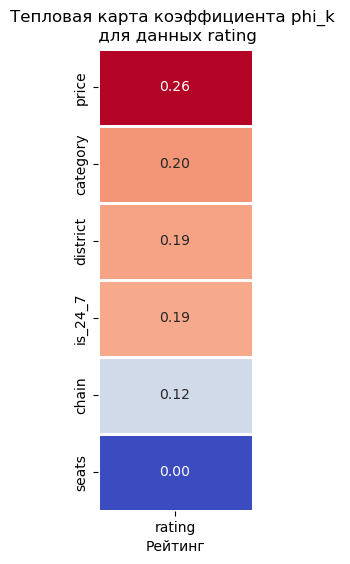

In [59]:
# Созадим контейнер для графика
plt.figure(figsize=(2, 6))

sns.heatmap(data=corr_matrix,
           annot=True,
           fmt='.2f',
           linewidth=1,
           cmap='coolwarm',
           cbar=False)

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')

# Выводим график
plt.show() 

На основании матрицы корреляции можно сделать вывод, что сильной корреляции между изучаемыми признаками и рейтингом нет. Наблюдается небольшая корреляция цены и рейтинга (коэффициент 0,26), чуть меньший коэффициент корреляции почти 0,2 у категории. Район и круглосуточная работа имеют близкие коэффициенты около 0,19, а вот сетевое ли заведение или нет имеет совсем небольшой коэффициент - 0,11. Связи с количеством посадочных мест нет совсем.

Наличие таких показателей объяснимо: ранее мы наблюдали, что рейтинг у некоторых категорий в среднем выше, чем в других категориях (например бар, паб в среднем оценивают лучше, а вот заведения быстрого питания оценивают немного хуже). Цены также часто выступают одним из важнейших критериев оценки продукта.

____
Проверим дополнительно распределение рейтинга для следующих столбцов `price`, `district`, `is_24_7` и `chain`

Расчет среднего и медианного значений рейтингов для заведений разных ценовых сегментов


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3711286898.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_rating_group_df = cleaned_df.groupby('price')['rating'].agg(['mean', 'median'])


,mean,median
price,,
высокие,4.4,4.4
выше среднего,4.4,4.4
средние,4.3,4.3
низкие,4.2,4.2


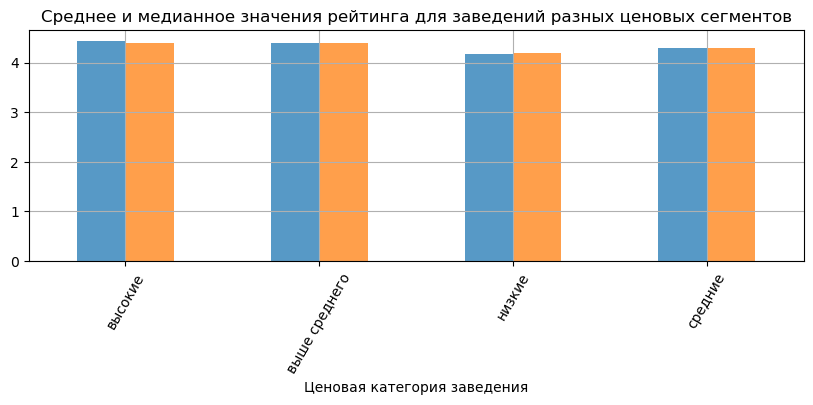

In [60]:
# Сгруппируем данные по ценовой категории
price_rating_group_df = cleaned_df.groupby('price')['rating'].agg(['mean', 'median'])
print('Расчет среднего и медианного значений рейтингов для заведений разных ценовых сегментов')
display(round(price_rating_group_df.sort_values('median', ascending=False), 1))

# Визуализируем на графике
price_rating_group_df.plot(kind='bar',
                       alpha=0.75,
                       rot=60,
                       title='Среднее и медианное значения рейтинга для заведений разных ценовых сегментов',
                       legend=False,
                        figsize=(10,3))

plt.xlabel('Ценовая категория заведения')
plt.grid()
plt.show()

Можно сделать вывод, что чем выше ценовой сегмент заведения, тем выше у него рейтинг, что можно объяснить тем, что с повышением цены растет и качество услуг.

Разница между рейтингами и средними оценками не большая: для заведений с ценовым сегментом «низкий» средний рейтинг 4,2, а для «высокого» ценового сегмента 4,4.

Дополнительно выведем разброс рейтингов для разных ценовых сегментов.

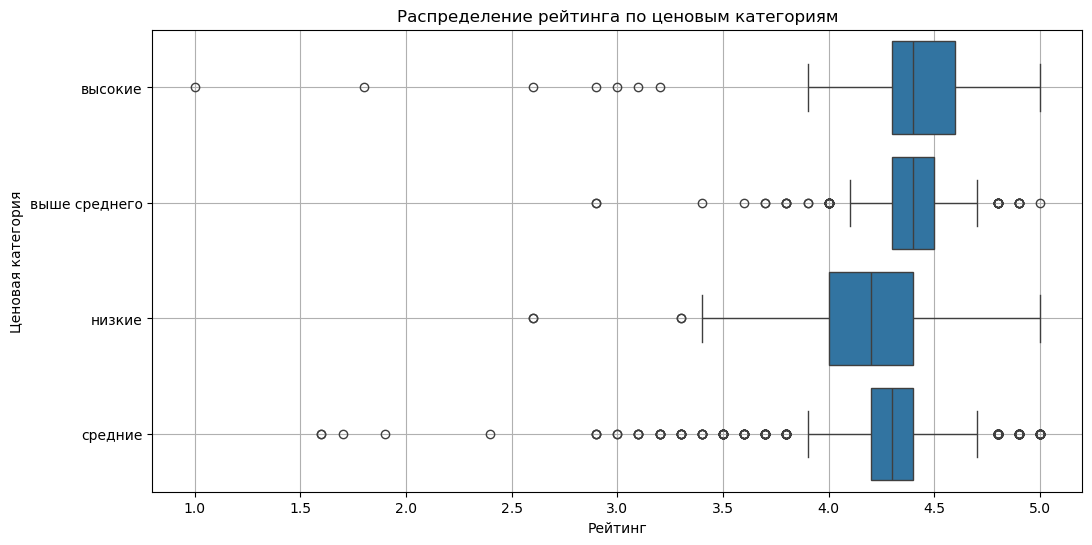

In [71]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=cleaned_df, x='rating', y='price')

plt.title('Распределение рейтинга по ценовым категориям')
plt.xlabel('Рейтинг')
plt.ylabel('Ценовая категория')
plt.grid()
plt.show()

Распределение оценок в разных ценовых сегментах различается. Наибольшие выбросы представлены в категории цен «высокие», премиальные клиенты ставят совсем плохие оценки, что может быть связано с более высокими ожиданиями при посещении дорогих заведений. Также большие выбросы есть в ценовом диапазоне «средних» цен, что может объясняться тем, что именно в этом сегменте основная масса заведений города, а значит можно предположить, что они с больше долей вероятности получают больше разных оценок. 

Основная масса оценок для ценовых сегментов «средний» и «низкий» немного смещена вниз относительно двух других сегментов, также стоит обратить внимание, что для категории «низкие» цены межквартильный размах больше, чем у всех остальных категория, что говорит о том, что в норме в таких заведениях встретить разный уровень качества: как хороший, так и плохой, в то время как например в сегменте «средний» размах меньше, а значит все заведения примерно одного качества.

___

Проверим взаимосвязи рейтинга и района

Расчет среднего и медианного значений рейтингов для заведений в разных районах


/var/folders/90/zy724dfn1m99mkh40l9zx2400000gn/T/ipykernel_14137/3483354510.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  district_rating_group_df = cleaned_df.groupby('district')['rating'].agg(['mean', 'median'])


,mean,median
district,,
центральный административный округ,4.4,4.4
восточный административный округ,4.2,4.3
западный административный округ,4.2,4.3
северный административный округ,4.2,4.3
северо-западный административный округ,4.2,4.3
юго-западный административный округ,4.2,4.3
южный административный округ,4.2,4.3
северо-восточный административный округ,4.1,4.2
юго-восточный административный округ,4.1,4.2


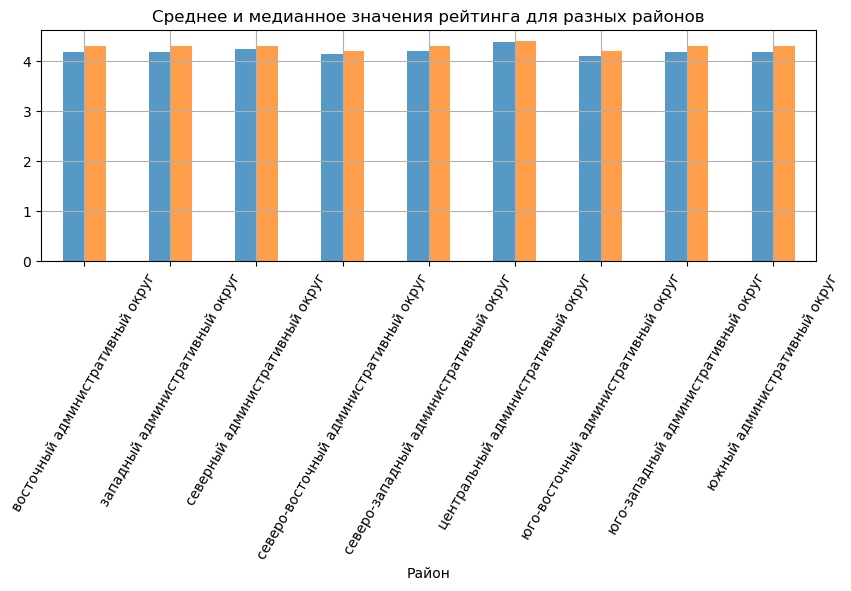

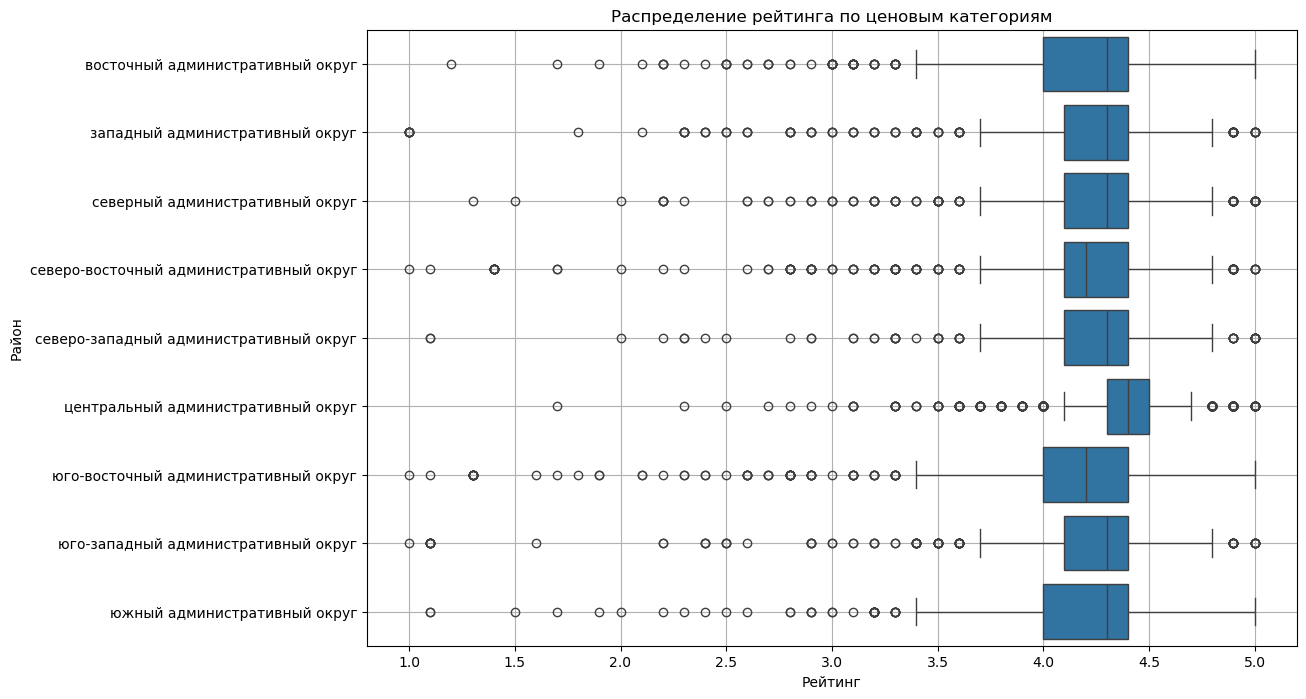

In [68]:
# Сгруппируем данные
district_rating_group_df = cleaned_df.groupby('district')['rating'].agg(['mean', 'median'])
print('Расчет среднего и медианного значений рейтингов для заведений в разных районах')
display(round(district_rating_group_df.sort_values('median', ascending=False), 1))

# Визуализируем на графике
district_rating_group_df.plot(kind='bar',
                       alpha=0.75,
                       rot=60,
                       title='Среднее и медианное значения рейтинга для разных районов',
                       legend=False,
                       figsize=(10,3))

plt.xlabel('Район')
plt.grid()

plt.figure(figsize=(12, 8))

sns.boxplot(data=cleaned_df, x='rating', y='district')

plt.title('Распределение рейтинга по ценовым категориям')
plt.xlabel('Рейтинг')
plt.ylabel('Район')
plt.grid()

plt.show()

Средние рейтинги для всех районов варьируются от 4,2 и до 4,4. Заведения с наилучшими показателями расположены центральном административном округе, в то время как в северо-восточном и юго-восточном административных округах средние оценки немного ниже (4,2). 
Можно наблюдать выбросы оценок в каждом из районов города. 

Стоит также обратить внимание на межквартильный размах: для ЦАО он минимальный, то есть в этом районе основная масса заведений сравнимого качества, что дополнительно подтверждается отсутствием совсем низких оценок, в то время как в восточном и южном округе размах достаточно большой, а значит и рейтинг заведений достаточно разный.

____

Проверим взаимосвязь режима работы и рейтинга

Расчет среднего и медианного значений рейтингов в зависимости от графика работы


,mean,median
is_24_7,,
0.0,4.3,4.3
1.0,4.1,4.2


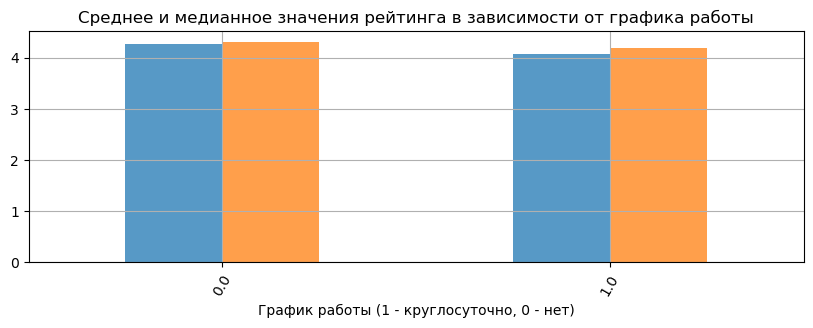

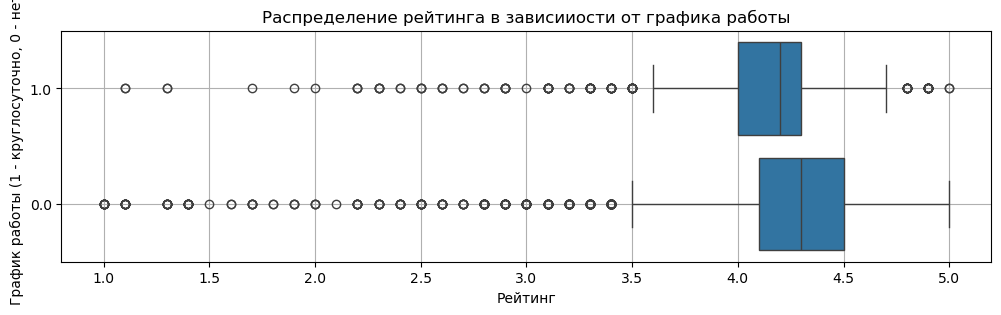

In [72]:
# Сгруппируем данные
is_24_7_rating_group_df = cleaned_df.groupby('is_24_7')['rating'].agg(['mean', 'median'])
print('Расчет среднего и медианного значений рейтингов в зависимости от графика работы')
display(round(is_24_7_rating_group_df.sort_values('median', ascending=False), 1))

# Визуализируем на графике
is_24_7_rating_group_df.plot(kind='bar',
                       alpha=0.75,
                       rot=60,
                       title='Среднее и медианное значения рейтинга в зависимости от графика работы',
                       legend=False,
                       figsize=(10,3))

plt.xlabel('График работы (1 - круглосуточно, 0 - нет)')
plt.grid()

plt.figure(figsize=(12, 3))

sns.boxplot(data=cleaned_df, x='rating', y=cleaned_df[cleaned_df['is_24_7'].notna()]['is_24_7'].astype(str))

plt.title('Распределение рейтинга в зависииости от графика работы')
plt.xlabel('Рейтинг')
plt.ylabel('График работы (1 - круглосуточно, 0 - нет)')
plt.grid()

plt.show()

Круглосуточные заведения имеют чуть более низкий средний рейтинг, но разница снова не так велика 4,2 против 4,3. Выбросы присутствуют в обеих группах. Заведения работающие по ограниченному графику имеют более широкий межквартильный размах, но учитывая, что таких заведений практически 90% такая ситуация объяснима. 

Более низкий рейтинг для круглосуточных заведений может быть связан со сложностью поддерживать высокое качество обслуживания без перерывов в работе, в то же время заведения с ограниченным временем работы чаще имеют выраженную концепцию (например семейный ресторан, смузи кафе), а значит в них с большей долей вероятности попадет именно целевая аудитория.

___

Проверим распределение оценок в сетевых и несетевых заведениях

Расчет среднего и медианного значений рейтингов в зависимости от признака сетевое заведение или нет


,mean,median
chain,,
0,4.2,4.3
1,4.2,4.3


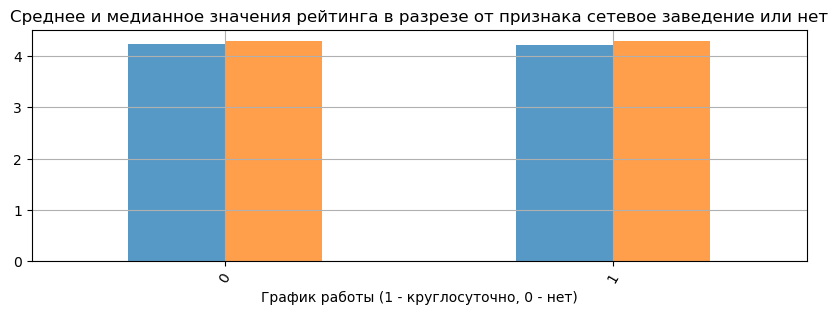

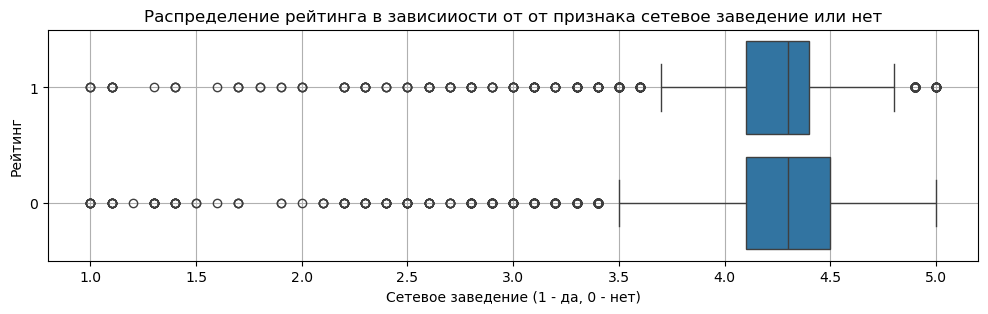

In [73]:
# Сгруппируем данные
chain_rating_group_df = cleaned_df.groupby('chain')['rating'].agg(['mean', 'median'])
print('Расчет среднего и медианного значений рейтингов в зависимости от признака сетевое заведение или нет')
display(round(chain_rating_group_df.sort_values('median', ascending=False), 1))

# Визуализируем на графике
chain_rating_group_df.plot(kind='bar',
                       alpha=0.75,
                       rot=60,
                       title='Среднее и медианное значения рейтинга в разрезе от признака сетевое заведение или нет',
                       legend=False,
                        figsize=(10,3))

plt.xlabel('График работы (1 - круглосуточно, 0 - нет)')
plt.grid()

plt.figure(figsize=(12, 3))

sns.boxplot(data=cleaned_df, x='rating', y=cleaned_df[cleaned_df['chain'].notna()]['chain'].astype(str))

plt.title('Распределение рейтинга в зависииости от от признака сетевое заведение или нет')
plt.xlabel('Сетевое заведение (1 - да, 0 - нет)')
plt.ylabel('Рейтинг')
plt.grid()

plt.show()

Разницы в среднем значении рейтинга сетевых и несетевых заведений нет, более широкий ящик с большим разбросом стандартных рейтингов объясним тем, что группа несетевых заведений сама по себе больше, а кроме того сетевые заведения за счет стандартизации зачастую имеют предлагают более предсказуемое качество.

___

**Промежуточный вывод** 
Наблюдается небольшая корреляция между признаками `price`, `district`, `is_24_7` и `chain` и рейтингом, при этом количество мест `seats` не имеет корреляции совсем.
Чем выше ценовой сегмент `price`, тем выше рейтинг, при этом чем более низкий ценовой сегмент, тем и разброс стандартных значений рейтингов выше, то есть выбирая дешевое заведение стоит более внимательно относиться к изучению отзывов, в то время как повышая ценовой сегмент можно уделять этому меньше значения, так как большая часть заведений будет сравнимого качества.

Категория заведения также имеет небольшую корреляцию с рейтингом, например бар, паб имеет более высокий средний рейтинг, а например кафе в среднем имеет более низкий рейтинг. 

Самый высокий средний рейтинг и минимальный разброс стандартных значений в центральном округе, что объяснимо, так как там сосредоточено большое количество заведений, а значит более высокая конкуренция, что побуждает больше внимания уделять сервису.

Заведения с ограниченным временем работы имеют чуть более высокие рейтинги, по сравнению с круглосуточными заведениями, а вот признак сетевое заведение или нет разницы в средних значениях не имеют. Разброс средних значений для сетевых заведений меньше, что объяснимо стандартизацией и более четкими ожиданиями посетителей.

<a id="#5_top_chain"></a>
## Анализ ТОП-15 популярных сетевых заведений

In [74]:
chain_grouped_df = (
    cleaned_df[cleaned_df['chain'] == 1]
    .groupby('name')
    .agg(
        chain_category=('category', 'first'),
        location_count=('name', 'count'),  
        mean_rating=('rating', 'mean')
    )
    .sort_values(by='location_count', ascending=False)
    .head(15)
)

chain_grouped_df['mean_rating'] = chain_grouped_df['mean_rating'].round(2) 

display(chain_grouped_df)

,chain_category,location_count,mean_rating
name,,,
шоколадница,кофейня,120,4.18
домино'с пицца,пиццерия,76,4.17
додо пицца,пиццерия,74,4.29
one price coffee,кофейня,71,4.06
яндекс лавка,ресторан,69,3.87
cofix,кофейня,65,4.08
prime,ресторан,50,4.12
хинкальная,ресторан,44,4.32
кофепорт,кофейня,42,4.15


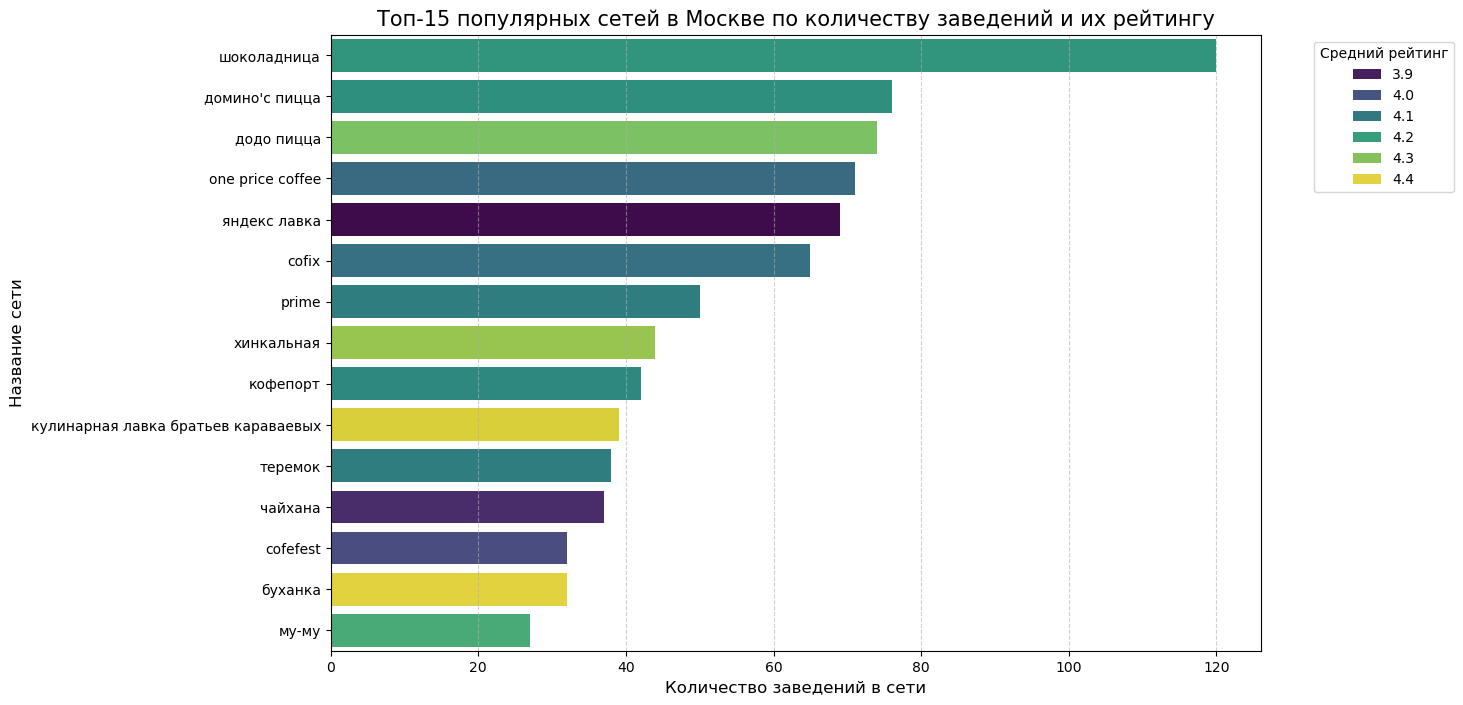

In [75]:
plt.figure(figsize=(12, 8))

# Создаем горизонтальный график
plot = sns.barplot(
    data=chain_grouped_df.reset_index(), 
    x='location_count', 
    y='name', 
    hue='mean_rating', 
    palette='viridis', 
    dodge=False
)

# Добавляем подписи данных на столбцы
#for i in plot.containers:
   #plot.bar_label(i, padding=5)

plt.title('Топ-15 популярных сетей в Москве по количеству заведений и их рейтингу', fontsize=15)
plt.xlabel('Количество заведений в сети', fontsize=12)
plt.ylabel('Название сети', fontsize=12)
plt.legend(title='Средний рейтинг', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

Доминирующими категориями среди ТОП-15 популярных сетевых заведений являются в основном заведения быстрого перекуса и кофе:  кофейни «Шоколадница», «One price Coffee», «Cofix» ресторанами «Яндекс лавка», «Теремок», пиццериями «Домино'с пицца» и «Додо пицца». Можно предположить, что такие форматы с достаточно быстрой подачей приготовленной заранее еды и ограниченного ассортимента легче всего масштабировать.

Стоит отметить, что самая распространенная сеть – это «Шоколадница», которая представлена 120 заведениями, при этом второе по популярности место «Домино'с пицца» отстает по количеству заведений почти на 35%. 

Рейтинг популярных заведений варьируется от 3.87 для ресторана «Яндекс лавка и до 4,4 для булочной «Буханка». Интересная закономерность, что более мелкие сети имеют как более высокие средние рейтинги, так и более низкие, можно предположить, что на этом этапе распространенности сети и происходит момент настройки стандартов обслуживания и дальнейший рост, либо такая разница может быть связана с более узким географическим положением. Для более точного понимания закономерностей можно дополнительно провести анализ места расположения сетей, а также проанализировать сколько по времени каждая из этих сетей работает. 

<a id="#6_summary"></a>
## Выводы

В ходе исследования проанализировали данные 8000 заведений общественного питания города Москвы. Данные информаци о заведениях и характеристиках. Акцент исследования был на том, чтобы найти взаимосвязи между рейтингом заведения и его характеристиками. Среди них: категория заведения, район расположения, ценовой сегмент, количество посадочных мест признаки сетевое заведение или нет, работает ли круглосуточно или нет.

### Профиль среднего заведения 

Исследовательский анализ данных позволил сформировать описание заведения общественного питания Москвы. Из 8000 проанализированных заведений среднее заведение - это:
- несетевое кафе
- в среднем ценовом сегменте
- рейтинг около 4,2-4,4
- расположенное в центральном округе
- имеет около 40-50 посадочных мест
- средний чек чуть больше 1000 рублей
- работает в ограниченном временном режиме (не круглосуточно).

Форматы сетевых заведений представлены в основном быстрой едой и кофе, ТОП-3 сети, с наибольшим количеством заведений – это «Шоколадница», «Домино'с пицца» и «Додо пицца». 


### Факторы коррелирующие с рейтингом

Как правило, чем выше ценовой сегмент заведения, тем выше рейтинг.
Если заведение расположено в центральном округе, то его рейтинг будет скорее выше.
Категория заведения также коррелирует с рейтингом, но наиболее популярная категория кафе имеет один из самых низких рейтингов, а более узкие концептуальные заведения тип баров,  пабов более высокий рейтинг. 
Заведения с ограниченным графиков работы зачастую имеют немного более высокий рейтинг по сравнению с круглосуточными.

В низком ценовом сегменте и в несетевых заведениях наблюдается самый большой разброс оценок. Это может значить, что в этих нишах нет «стандарта», поэтому и риски там выше.

Стоит отметить, что само по себе количество посадочных мест практически не влияет на рейтинг, поэтому нет смысла гнаться за большими площадями или очень большой посадкой.

### Рекомендации

При выборе какое заведение открывать в Москве стоит обратить внимание как на тип заведения, так и на расположение, так как наиболее популярный формат кафе в среднем ценовом сегменте в популярном центре может стать сложной задачей, так как конкуренция достаточно высокая. В районе много заведений такого типа, при этом они имеют хороший рейтинг, то есть для ожиданий посетителей уже задана достаточно высокая планка. При этом стоит учитывать, что сетевой формат является залогом предсказуемого качества и рейтинга не ниже 4.1, однако для достижения максимально высоких оценок (4.5 и выше) более выигрышными оказываются уникальные несетевые концепции (бары, кофейни), при условии жесткого контроля качества. 

Наименее выигрышный формат круглосуточное заведение в низком ценовом сегменте на окраине. Такие заведения как правило имеют более низкий рейтинг.

**Наименее рискованная стратегия**: открывать типичное заведение (кафе или ресторан) в популярном районе  ЦАО. Основной плюс: есть софрмированный спрос, понятные «стратегии». Минусы: высокая конккуренция, сложно выделиться среди такого количества кафе, а также дополнительно стоит рассчитывать модель окупаемости при среднем чеке почти в 1200.

Среди **более рискованных стратегий** можно рассмотерть разные пути: 
- Выбрать менее популярный тип  более узконаправленный тип завдениия, например бар, пицерия или булочная. Плюсы: чуть меньше конкуренция, более узкий ассортимент блюд и напитков, что может помочь сделать их более качественными за  счет спциализации. Минусы: не гарантированный спрос, сложно «поймать» идею, которая действительно понравится клиентам. 
- Выбрать район с меньшим количеством заведений и низким средним чеком (например, юго-востоный округ - в нем сосредоточено 8,5% заведений против 26,7% в ЦАО и при этом средний чек 450 рублей против 1200 в ЦАО). Плюсы: меньше конкуренция, проще выделиться на фоне качеством и новизной. Минусы: более низкий средний чек коррелирцет с рейтингом, то есть скорее всего будет сложно получить «высокие» оценки, кроме того в районе может быть недостаточный спрос, который обеспечит нужный уровень доходности.
- Открыть сетефое заведение. Плюс: за счет узнаваемости бренда можно расширять сеть и охватывать большее количество клиентов, экономия на массовых закупках оборудования и оборотных средсвт. Минусы: высокая конкуренция с уже узнаваемыми брендами влечет высокие маркетинговые расходы, также отркытие сетевого заведения требует крпных первоначальных затрат.